In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

%matplotlib inline
plt.rcParams["figure.dpi"] = 130

In [4]:
CKPT_PATH = "baseline_results/models/BaselineEfficientNetB2_best.pth"

SEMANTIC_GROUPS = [
    "contamination", "cut", "deformation", "fracture",
    "hole_void", "minor_defect", "scratch", "surface_quality",
]

C_TRAIN = "#1565C0"
C_VAL   = "#C62828"
C_BEST  = "#2E7D32"
C_F1    = "#2E7D32"
C_PREC  = "#1565C0"
C_REC   = "#E65100"

DATASET_COLORS = {
    "mvtec":    "#1565C0",
    "casting":  "#C62828",
    "magnetic": "#2E7D32",
    "unknown":  "#757575",
}

CLASS_COLORS = [
    "#E53935", "#8E24AA", "#1E88E5", "#43A047",
    "#FB8C00", "#00ACC1", "#6D4C41", "#757575",
]

plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F8F9FA",
    "axes.grid":          True,
    "grid.alpha":         0.35,
    "grid.color":         "#CCCCCC",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

In [5]:
ckpt     = torch.load(CKPT_PATH, map_location="cpu")
history  = ckpt["history"]
test_res = ckpt.get("test_results", {})

# Convert per-class lists-of-lists to numpy (epochs × 8)
for key in ("val_per_class_f1", "val_per_class_p", "val_per_class_r"):
    if key in history and len(history[key]):
        history[key] = np.array(history[key], dtype=float)

# Find best epoch
scores     = history.get("val_score", [])
epochs_arr = history.get("epoch", [])
best_epoch = int(epochs_arr[int(np.argmax(scores))]) if scores else epochs_arr[-1]
best_idx   = list(epochs_arr).index(best_epoch)

print(f"Epochs trained : {len(epochs_arr)}")
print(f"Best epoch     : {best_epoch}")
print(f"Best val F1    : {max(history.get('val_f1', [0.])):.4f}")
print(f"Test results   : {'YES' if test_res else 'NO'}")
if test_res:
    print(f"Test bin acc   : {test_res.get('binary_acc', 0.):.2f}%")
    print(f"Test defect F1 : {test_res.get('defect_f1', 0.):.4f}")
    print(f"Test ROC-AUC   : {test_res.get('roc_auc', 0.):.4f}")

Epochs trained : 45
Best epoch     : 45
Best val F1    : 0.9479
Test results   : YES
Test bin acc   : 99.16%
Test defect F1 : 0.9201
Test ROC-AUC   : 0.9970


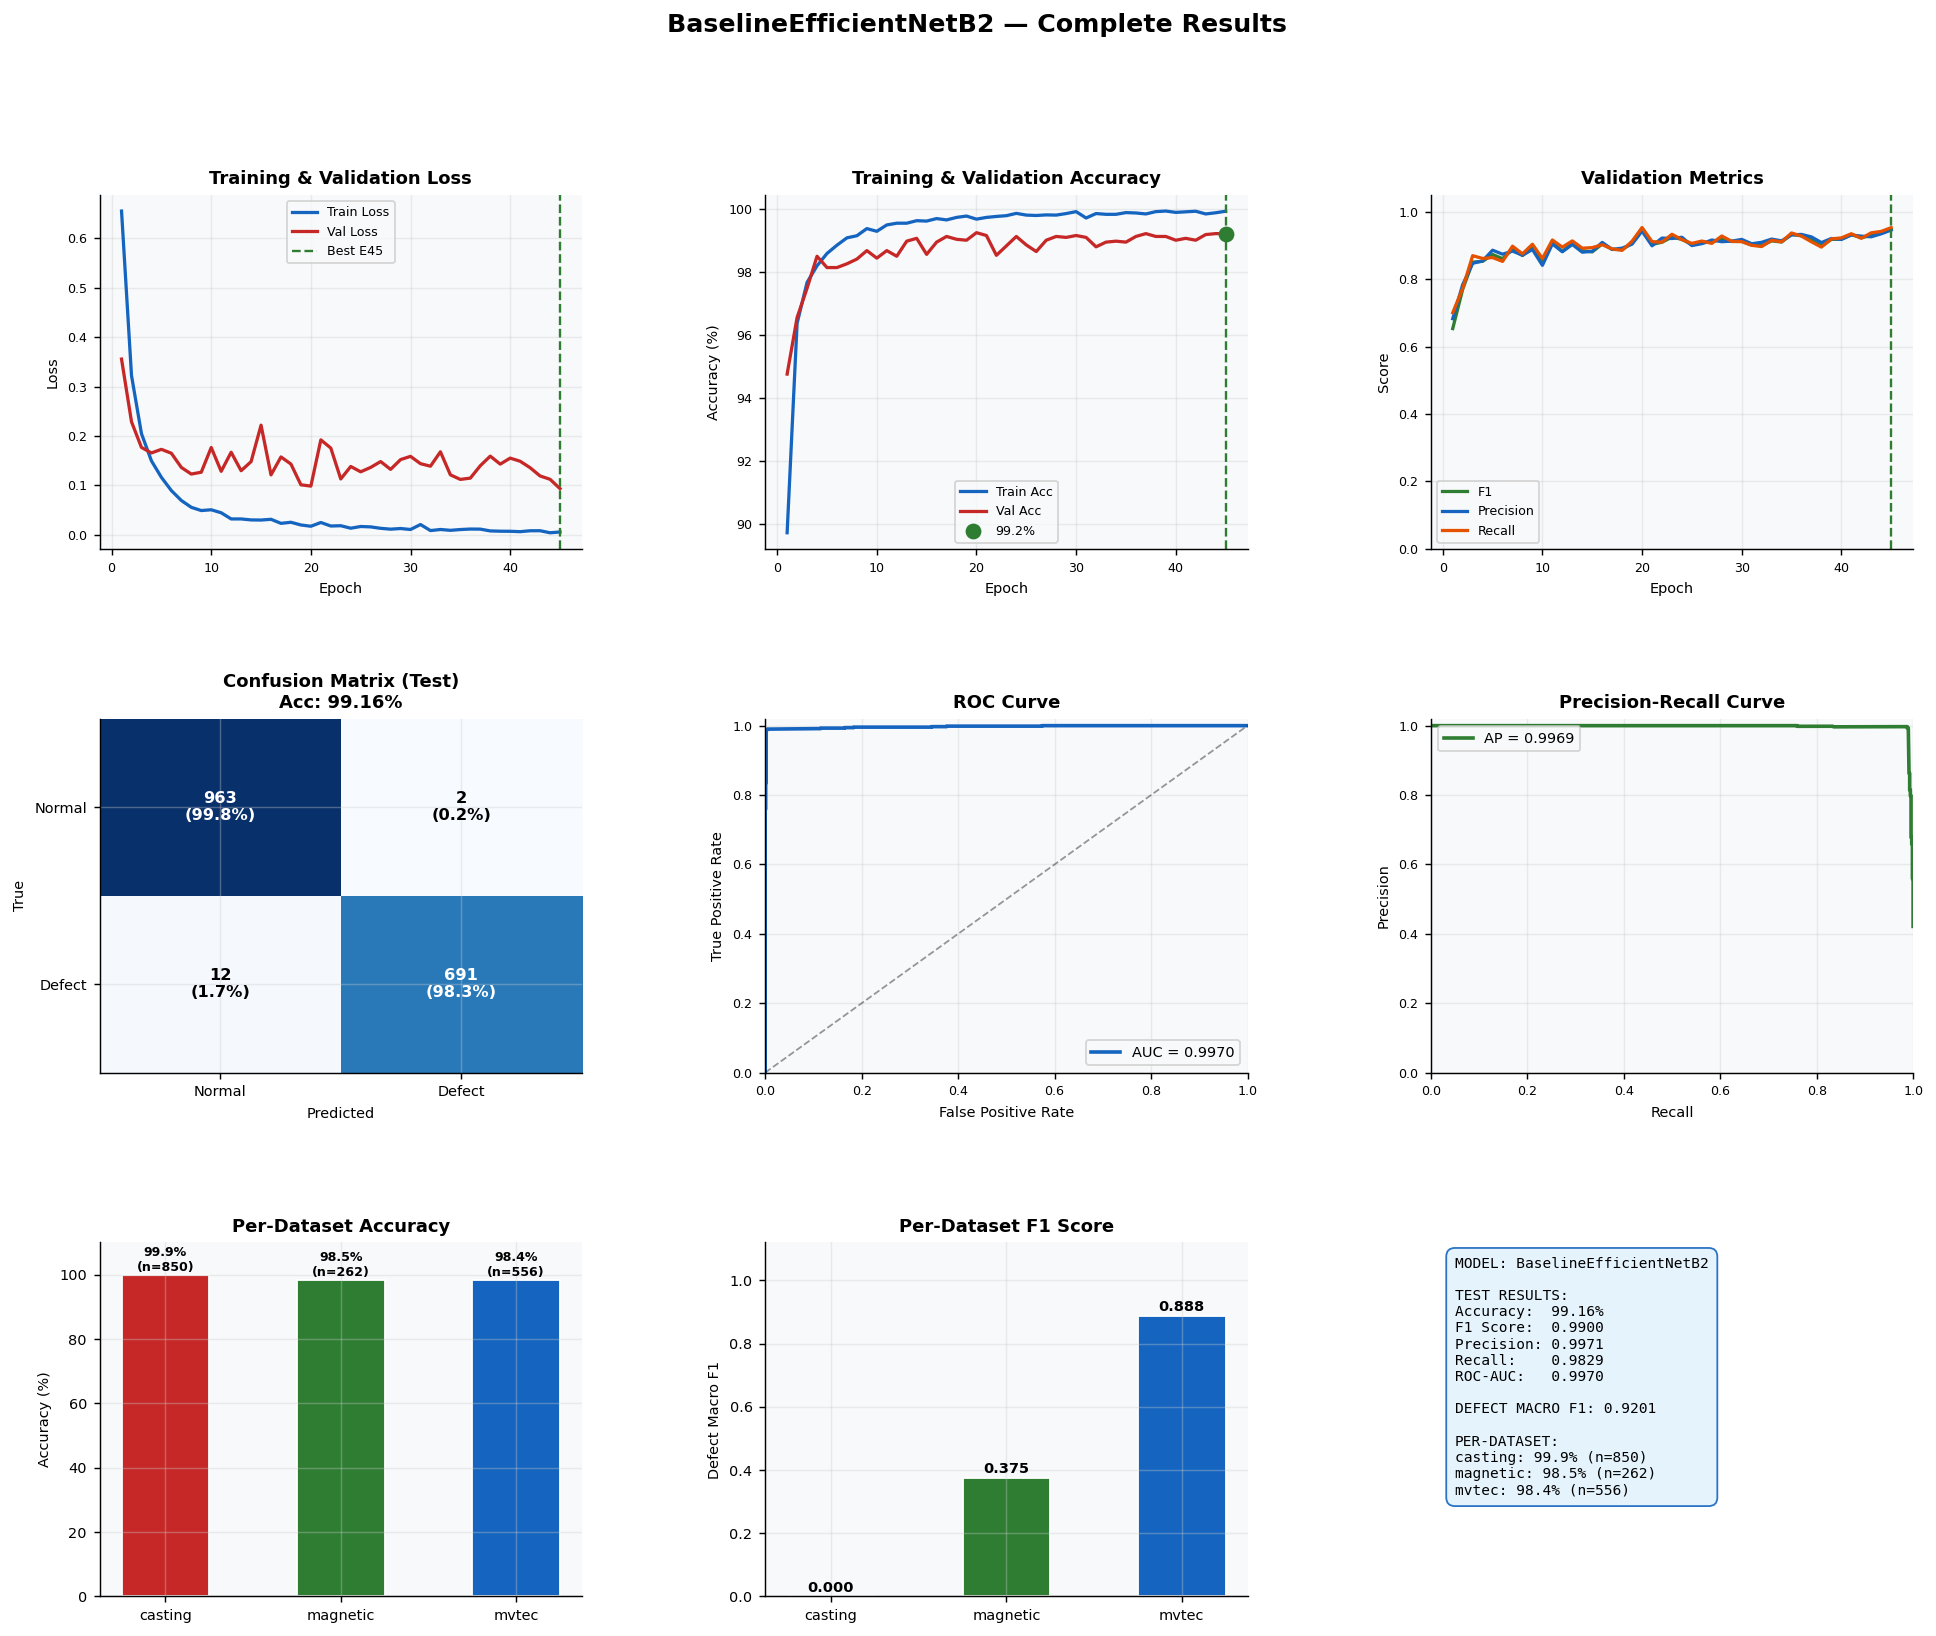

Saved: complete_results.png


In [6]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("BaselineEfficientNetB2 — Complete Results",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)
e  = history["epoch"]

# ── Row 0: Loss | Accuracy | Val Metrics ─────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(e, history["train_loss"], color=C_TRAIN, lw=1.8, label="Train Loss")
ax.plot(e, history["val_loss"],   color=C_VAL,   lw=1.8, label="Val Loss")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, label=f"Best E{best_epoch}")
ax.set_title("Training & Validation Loss", fontsize=10, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=8); ax.set_ylabel("Loss", fontsize=8)
ax.legend(fontsize=7); ax.tick_params(labelsize=7)

ax = fig.add_subplot(gs[0, 1])
ax.plot(e, history["train_binary_acc"], color=C_TRAIN, lw=1.8, label="Train Acc")
ax.plot(e, history["val_binary_acc"],   color=C_VAL,   lw=1.8, label="Val Acc")
ax.scatter(best_epoch, history["val_binary_acc"][best_idx],
           color=C_BEST, s=60, zorder=6,
           label=f"{history['val_binary_acc'][best_idx]:.1f}%")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3)
ax.set_title("Training & Validation Accuracy", fontsize=10, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=8); ax.set_ylabel("Accuracy (%)", fontsize=8)
ax.legend(fontsize=7); ax.tick_params(labelsize=7)

ax = fig.add_subplot(gs[0, 2])
ax.plot(e, history["val_f1"],   color=C_F1,   lw=1.8, label="F1")
ax.plot(e, history["val_prec"], color=C_PREC, lw=1.8, label="Precision")
ax.plot(e, history["val_rec"],  color=C_REC,  lw=1.8, label="Recall")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3)
ax.set_title("Validation Metrics", fontsize=10, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=8); ax.set_ylabel("Score", fontsize=8)
ax.set_ylim(0, 1.05); ax.legend(fontsize=7); ax.tick_params(labelsize=7)

# ── Row 1: Binary CM | ROC | PR ──────────────────────────────────────────
if test_res:
    ax  = fig.add_subplot(gs[1, 0])
    cm  = np.array(test_res["binary_cm"])
    rs  = cm.sum(axis=1, keepdims=True).clip(1)
    cmn = cm.astype(float) / rs
    ax.imshow(cm, cmap="Blues", aspect="auto")
    labs = ["Normal", "Defect"]
    ax.set_xticks([0,1]); ax.set_xticklabels(labs, fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(labs, fontsize=8)
    for i in range(2):
        for j in range(2):
            clr = "white" if cmn[i,j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i,j]}\n({cmn[i,j]*100:.1f}%)",
                    ha="center", va="center", fontsize=9,
                    color=clr, fontweight="bold")
    ax.set_title(f"Confusion Matrix (Test)\nAcc: {test_res.get('binary_acc',0.):.2f}%",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("True", fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(test_res["fpr"], test_res["tpr"],
            color=C_PREC, lw=2, label=f"AUC = {test_res['roc_auc']:.4f}")
    ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
    ax.set_title("ROC Curve", fontsize=10, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=8)
    ax.set_ylabel("True Positive Rate",  fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    ax.legend(fontsize=8, loc="lower right"); ax.tick_params(labelsize=7)

    ax = fig.add_subplot(gs[1, 2])
    ax.plot(test_res["pr_rec"], test_res["pr_prec"],
            color=C_F1, lw=2, label=f"AP = {test_res['ap']:.4f}")
    ax.set_title("Precision-Recall Curve", fontsize=10, fontweight="bold")
    ax.set_xlabel("Recall", fontsize=8); ax.set_ylabel("Precision", fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    ax.legend(fontsize=8); ax.tick_params(labelsize=7)

# ── Row 2: Per-dataset Acc | Per-dataset F1 | Info box ───────────────────
if test_res:
    pd_ = test_res.get("per_dataset", {})
    srcs = sorted(pd_.keys())

    ax = fig.add_subplot(gs[2, 0])
    accs   = [pd_[s]["binary_acc"] for s in srcs]
    ns     = [pd_[s]["n"]          for s in srcs]
    colors = [DATASET_COLORS.get(s,"#757575") for s in srcs]
    bars = ax.bar(srcs, accs, color=colors, width=0.5, edgecolor="white")
    for bar, a, n in zip(bars, accs, ns):
        ax.text(bar.get_x()+bar.get_width()/2, a+0.3,
                f"{a:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_title("Per-Dataset Accuracy", fontsize=10, fontweight="bold")
    ax.set_ylabel("Accuracy (%)", fontsize=8); ax.set_ylim(0, 110); ax.tick_params(labelsize=8)

    ax = fig.add_subplot(gs[2, 1])
    f1s  = [pd_[s]["defect_f1"] for s in srcs]
    bars = ax.bar(srcs, f1s, color=colors, width=0.5, edgecolor="white")
    for bar, f in zip(bars, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, f+0.005,
                f"{f:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title("Per-Dataset F1 Score", fontsize=10, fontweight="bold")
    ax.set_ylabel("Defect Macro F1", fontsize=8); ax.set_ylim(0,1.12); ax.tick_params(labelsize=8)

    ax = fig.add_subplot(gs[2, 2]); ax.axis("off")
    lines = [
        "MODEL: BaselineEfficientNetB2", "",
        "TEST RESULTS:",
        f"Accuracy:  {test_res.get('binary_acc',0.):.2f}%",
        f"F1 Score:  {test_res.get('binary_f1',0.):.4f}",
        f"Precision: {test_res.get('binary_prec',0.):.4f}",
        f"Recall:    {test_res.get('binary_rec',0.):.4f}",
        f"ROC-AUC:   {test_res.get('roc_auc',0.):.4f}",
        "", f"DEFECT MACRO F1: {test_res.get('defect_f1',0.):.4f}",
        "", "PER-DATASET:",
    ]
    for s, m in sorted(pd_.items()):
        lines.append(f"{s}: {m['binary_acc']:.1f}% (n={m['n']})")
    ax.text(0.05, 0.96, "\n".join(lines), transform=ax.transAxes,
            fontsize=8, va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#E3F2FD",
                      edgecolor="#1565C0", alpha=0.9))

plt.savefig("complete_results.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: complete_results.png")

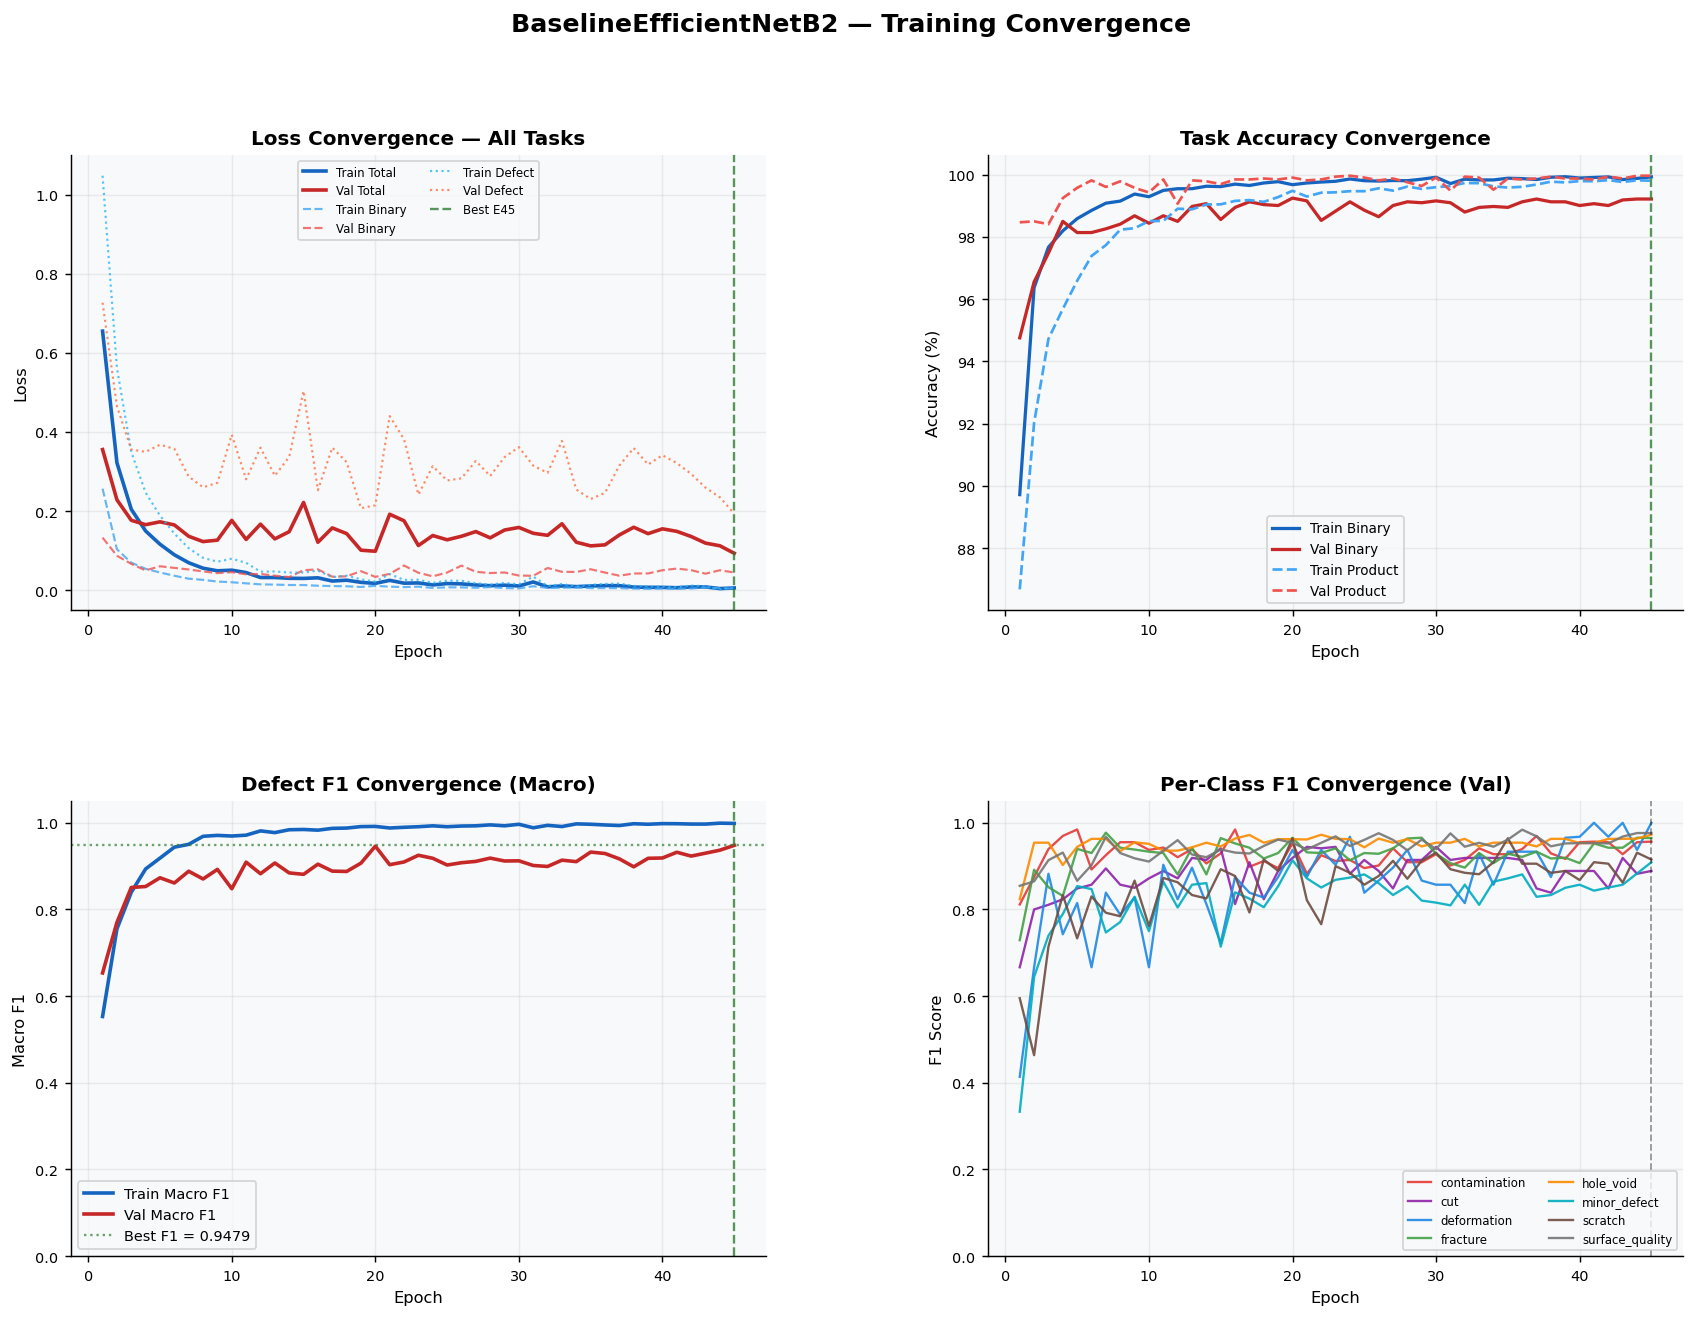

Saved: training_convergence.png


In [7]:
fig = plt.figure(figsize=(16, 11))
fig.suptitle("BaselineEfficientNetB2 — Training Convergence",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
e  = history["epoch"]

# ── A: All losses ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(e, history["train_loss"],        color=C_TRAIN,   lw=2.0, label="Train Total")
ax.plot(e, history["val_loss"],          color=C_VAL,     lw=2.0, label="Val Total")
ax.plot(e, history["train_binary_loss"], color="#42A5F5", lw=1.2, ls="--", alpha=0.8, label="Train Binary")
ax.plot(e, history["val_binary_loss"],   color="#EF5350", lw=1.2, ls="--", alpha=0.8, label="Val Binary")
ax.plot(e, history["train_defect_loss"], color="#29B6F6", lw=1.2, ls=":",  alpha=0.8, label="Train Defect")
ax.plot(e, history["val_defect_loss"],   color="#FF7043", lw=1.2, ls=":",  alpha=0.8, label="Val Defect")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, alpha=0.8, label=f"Best E{best_epoch}")
ax.set_title("Loss Convergence — All Tasks", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=9); ax.set_ylabel("Loss", fontsize=9)
ax.legend(fontsize=6.5, ncol=2); ax.tick_params(labelsize=8)

# ── B: Task accuracies ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(e, history["train_binary_acc"],  color=C_TRAIN,   lw=1.8, label="Train Binary")
ax.plot(e, history["val_binary_acc"],    color=C_VAL,     lw=1.8, label="Val Binary")
ax.plot(e, history["train_product_acc"], color="#42A5F5", lw=1.5, ls="--", label="Train Product")
ax.plot(e, history["val_product_acc"],   color="#EF5350", lw=1.5, ls="--", label="Val Product")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, alpha=0.8)
ax.set_title("Task Accuracy Convergence", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=9); ax.set_ylabel("Accuracy (%)", fontsize=9)
ax.legend(fontsize=7.5); ax.tick_params(labelsize=8)

# ── C: Macro defect F1 ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(e, history["train_f1"], color=C_TRAIN, lw=2.0, label="Train Macro F1")
ax.plot(e, history["val_f1"],   color=C_VAL,   lw=2.0, label="Val Macro F1")
best_f1 = float(np.max(history["val_f1"]))
ax.axhline(best_f1, color=C_BEST, ls=":", lw=1.3, alpha=0.7, label=f"Best F1 = {best_f1:.4f}")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, alpha=0.8)
ax.set_title("Defect F1 Convergence (Macro)", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=9); ax.set_ylabel("Macro F1", fontsize=9)
ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.tick_params(labelsize=8)

# ── D: Per-class F1 convergence ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
pcf1 = history.get("val_per_class_f1")
if pcf1 is not None and len(pcf1):
    pcf1 = np.asarray(pcf1)   # shape: (epochs, 8)
    for i, (cls, clr) in enumerate(zip(SEMANTIC_GROUPS, CLASS_COLORS)):
        ax.plot(e, pcf1[:, i], color=clr, lw=1.3, label=cls, alpha=0.9)
    ax.axvline(best_epoch, color="black", ls="--", lw=1.0, alpha=0.4)
ax.set_title("Per-Class F1 Convergence (Val)", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=9); ax.set_ylabel("F1 Score", fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=6.5, ncol=2, loc="lower right"); ax.tick_params(labelsize=8)

plt.savefig("training_convergence.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: training_convergence.png")

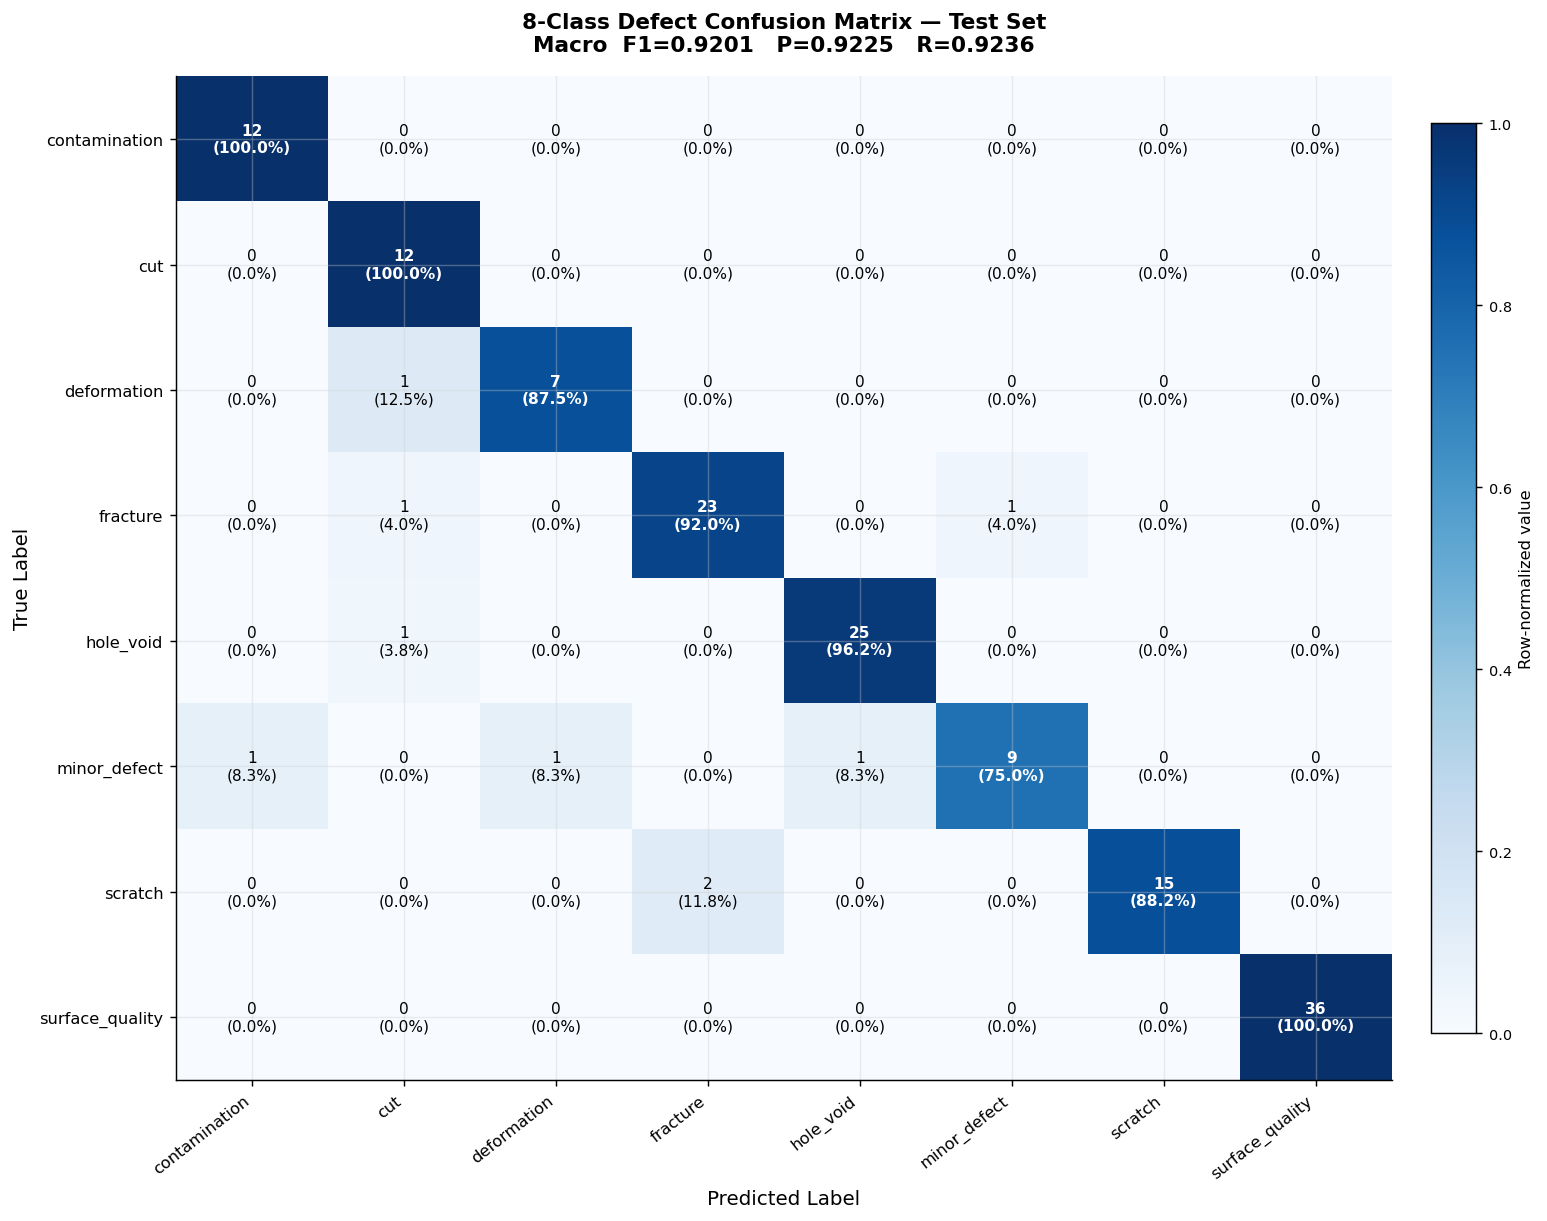

Saved: defect_confusion_matrix.png


In [8]:
if test_res and "defect_cm" in test_res:
    cm      = np.array(test_res["defect_cm"])    # (8, 8)
    rs      = cm.sum(axis=1, keepdims=True).clip(1)
    cm_norm = cm.astype(float) / rs

    fig, ax = plt.subplots(figsize=(12, 9.5))
    im   = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Row-normalized value", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xticklabels(SEMANTIC_GROUPS, rotation=38, ha="right", fontsize=9)
    ax.set_yticklabels(SEMANTIC_GROUPS, fontsize=9)

    for i in range(8):
        for j in range(8):
            raw  = int(cm[i, j])
            pct  = cm_norm[i, j] * 100
            clr  = "white" if cm_norm[i, j] > 0.55 else "black"
            bold = "bold" if i == j else "normal"
            ax.text(j, i, f"{raw}\n({pct:.1f}%)",
                    ha="center", va="center",
                    fontsize=8.5, color=clr, fontweight=bold)

    df1   = test_res.get("defect_f1",   0.)
    dprec = test_res.get("defect_prec", 0.)
    drec  = test_res.get("defect_rec",  0.)
    ax.set_title(
        f"8-Class Defect Confusion Matrix — Test Set\n"
        f"Macro  F1={df1:.4f}   P={dprec:.4f}   R={drec:.4f}",
        fontsize=12, fontweight="bold", pad=14)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label",      fontsize=11)

    plt.tight_layout()
    plt.savefig("defect_confusion_matrix.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: defect_confusion_matrix.png")
else:
    print("No test_results in checkpoint — skipping defect CM.")

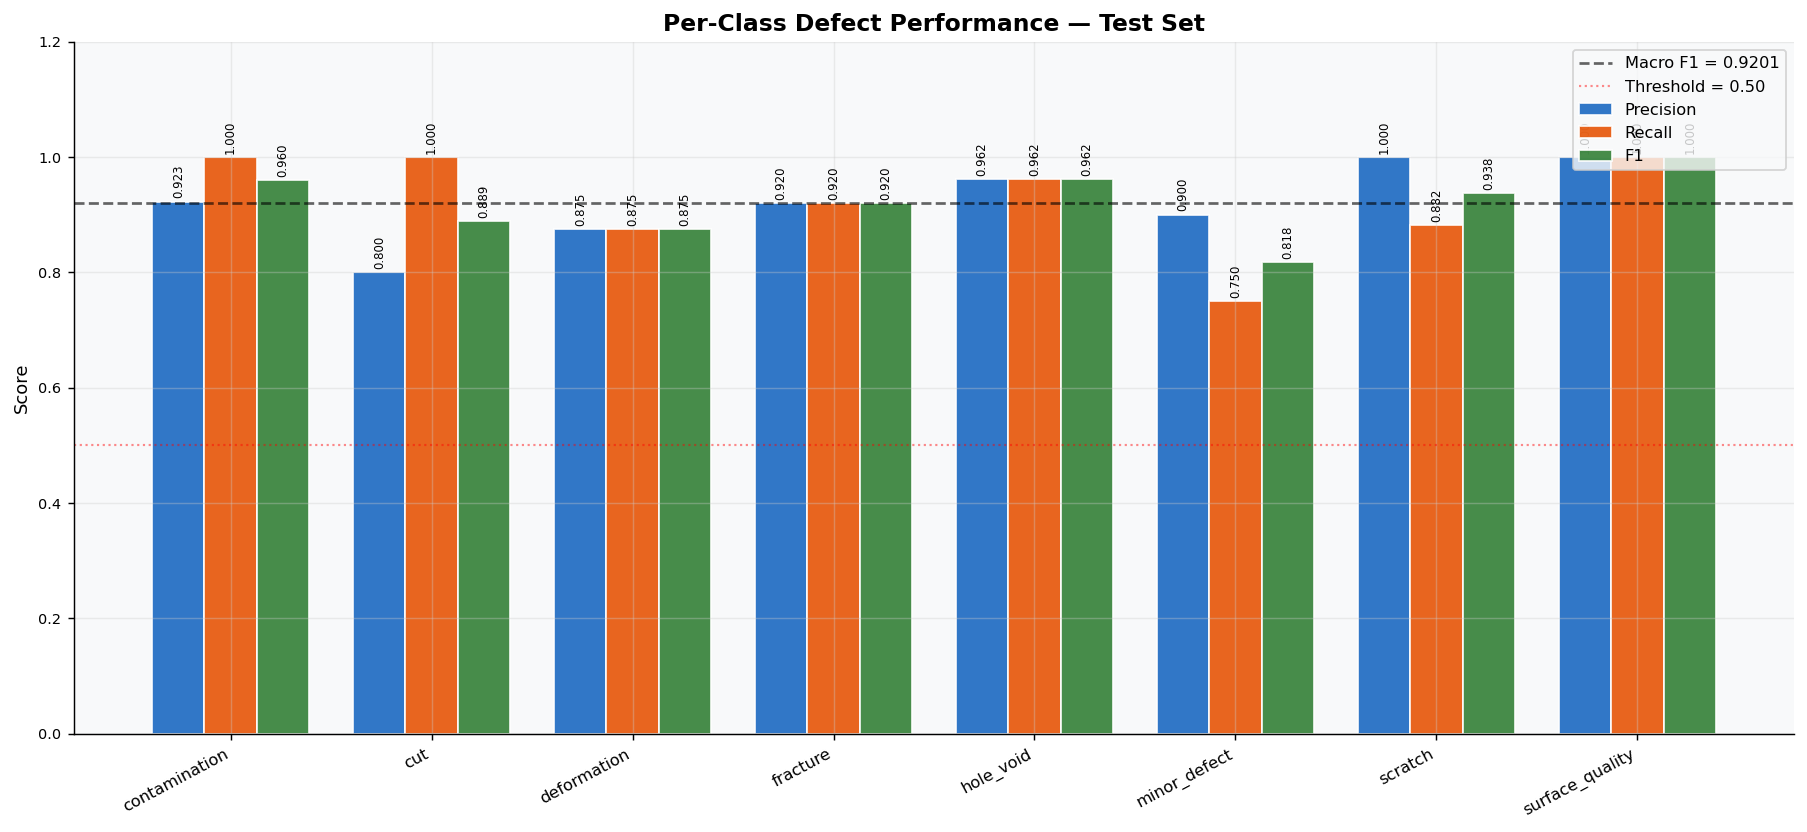

Saved: per_class_performance.png


In [9]:
if test_res and "per_class_f1" in test_res:
    pc_f1 = np.array(test_res["per_class_f1"])
    pc_p  = np.array(test_res["per_class_p"])
    pc_r  = np.array(test_res["per_class_r"])

    x     = np.arange(8)
    width = 0.26

    fig, ax = plt.subplots(figsize=(14, 6.5))
    b1 = ax.bar(x - width, pc_p,  width, label="Precision", color=C_PREC, alpha=0.88, edgecolor="white")
    b2 = ax.bar(x,         pc_r,  width, label="Recall",    color=C_REC,  alpha=0.88, edgecolor="white")
    b3 = ax.bar(x + width, pc_f1, width, label="F1",        color=C_F1,   alpha=0.88, edgecolor="white")

    for bars in (b1, b2, b3):
        for bar in bars:
            h = bar.get_height()
            if h > 0.02:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.006,
                        f"{h:.3f}", ha="center", va="bottom",
                        fontsize=6.5, rotation=90)

    macro_f1 = test_res.get("defect_f1", 0.)
    ax.axhline(macro_f1, color="black", ls="--", lw=1.5, alpha=0.6,
               label=f"Macro F1 = {macro_f1:.4f}")
    ax.axhline(0.50, color="red", ls=":", lw=1.2, alpha=0.45,
               label="Threshold = 0.50")

    ax.set_xticks(x)
    ax.set_xticklabels(SEMANTIC_GROUPS, rotation=28, ha="right", fontsize=9)
    ax.set_ylabel("Score", fontsize=10); ax.set_ylim(0, 1.20)
    ax.set_title("Per-Class Defect Performance — Test Set",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper right")
    ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.savefig("per_class_performance.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: per_class_performance.png")
else:
    print("No test_results in checkpoint — skipping per-class bars.")

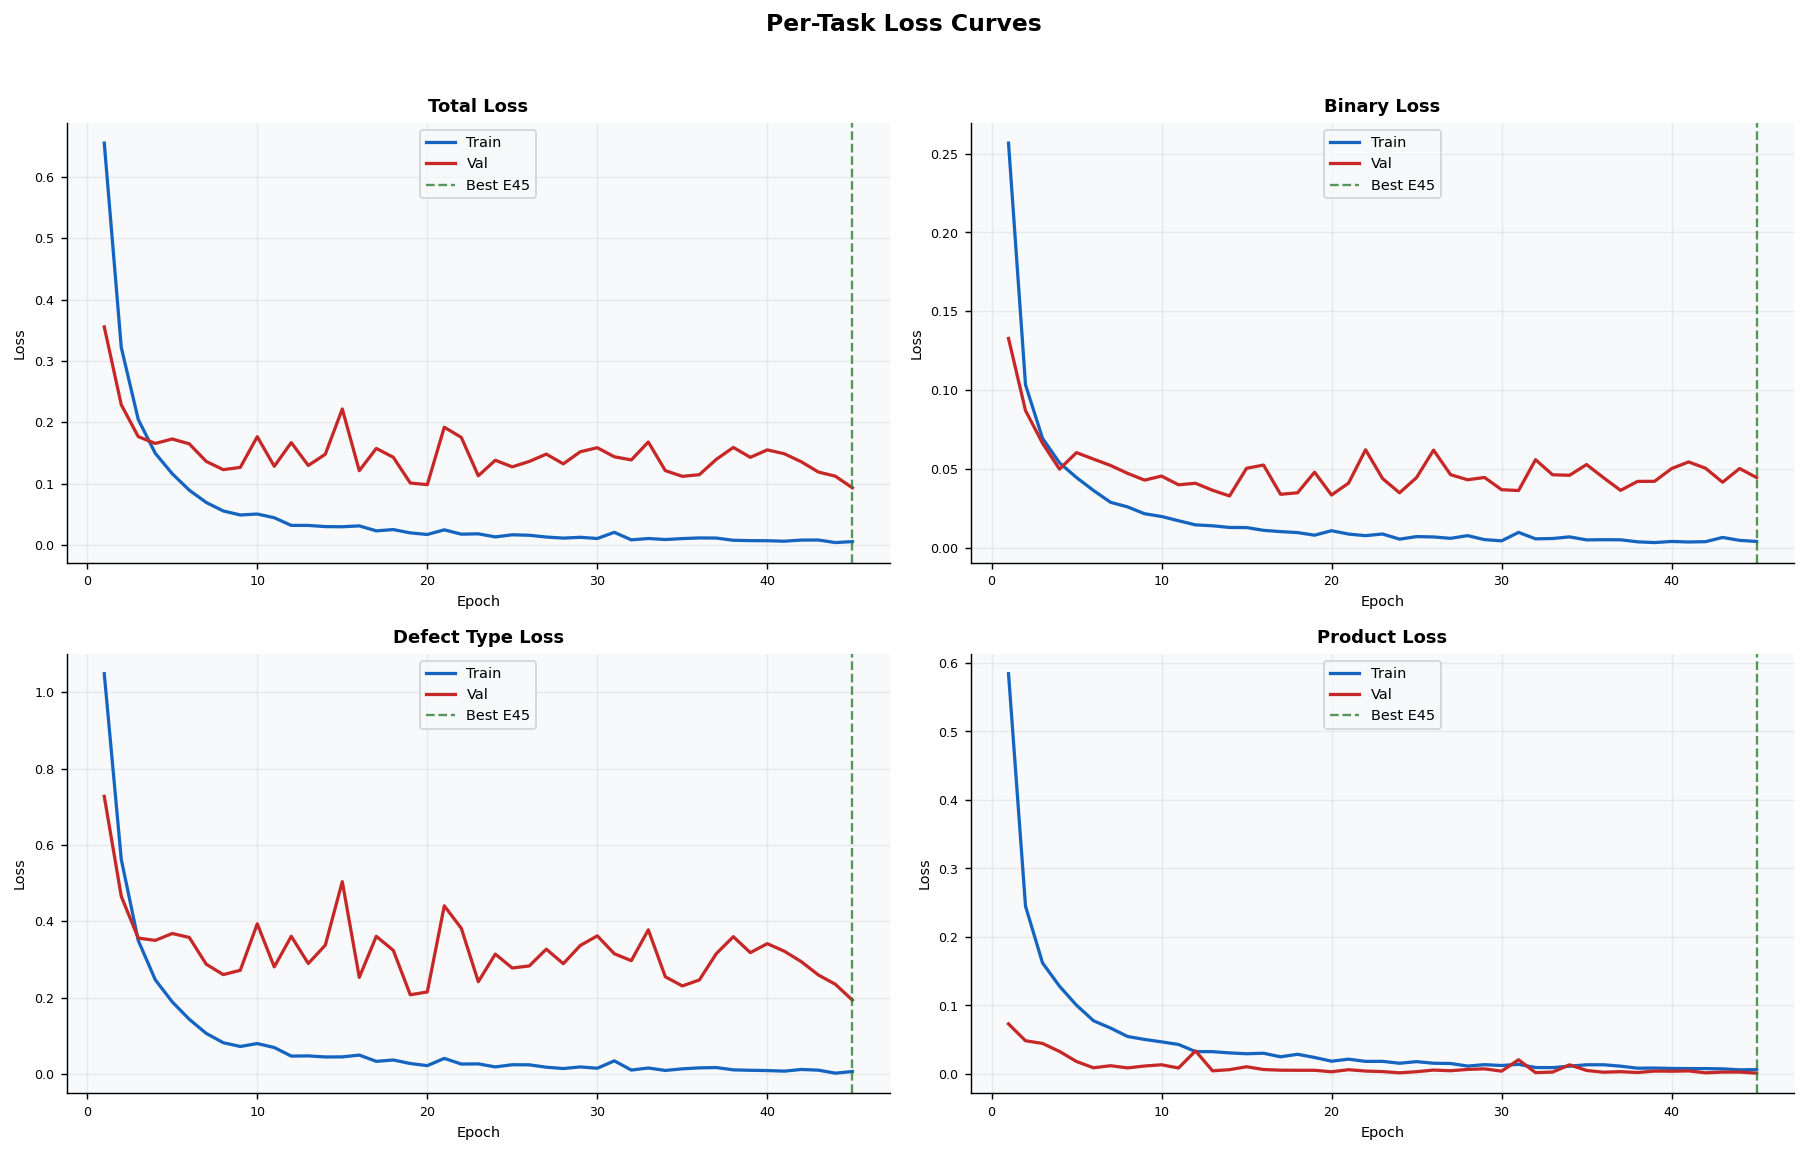

Saved: per_task_losses.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Per-Task Loss Curves", fontsize=13, fontweight="bold")
e = history["epoch"]

tasks = [
    ("loss",         "Total Loss",       axes[0, 0]),
    ("binary_loss",  "Binary Loss",      axes[0, 1]),
    ("defect_loss",  "Defect Type Loss", axes[1, 0]),
    ("product_loss", "Product Loss",     axes[1, 1]),
]
for key, title, ax in tasks:
    tk, vk = f"train_{key}", f"val_{key}"
    if tk in history:
        ax.plot(e, history[tk], color=C_TRAIN, lw=1.8, label="Train")
        ax.plot(e, history[vk], color=C_VAL,   lw=1.8, label="Val")
        ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3,
                   alpha=0.8, label=f"Best E{best_epoch}")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=8); ax.set_ylabel("Loss", fontsize=8)
    ax.legend(fontsize=8); ax.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("per_task_losses.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: per_task_losses.png")

In [11]:
from pathlib import Path

print("=" * 50)
print("  All graphs generated:")
print("=" * 50)
for name in [
    "complete_results.png",
    "training_convergence.png",
    "defect_confusion_matrix.png",
    "per_class_performance.png",
    "per_task_losses.png",
]:
    p = Path(name)
    status = f"{p.stat().st_size // 1024} KB" if p.exists() else "NOT FOUND"
    print(f"  {name:<40} {status}")

  All graphs generated:
  complete_results.png                     272 KB
  training_convergence.png                 338 KB
  defect_confusion_matrix.png              148 KB
  per_class_performance.png                93 KB
  per_task_losses.png                      184 KB


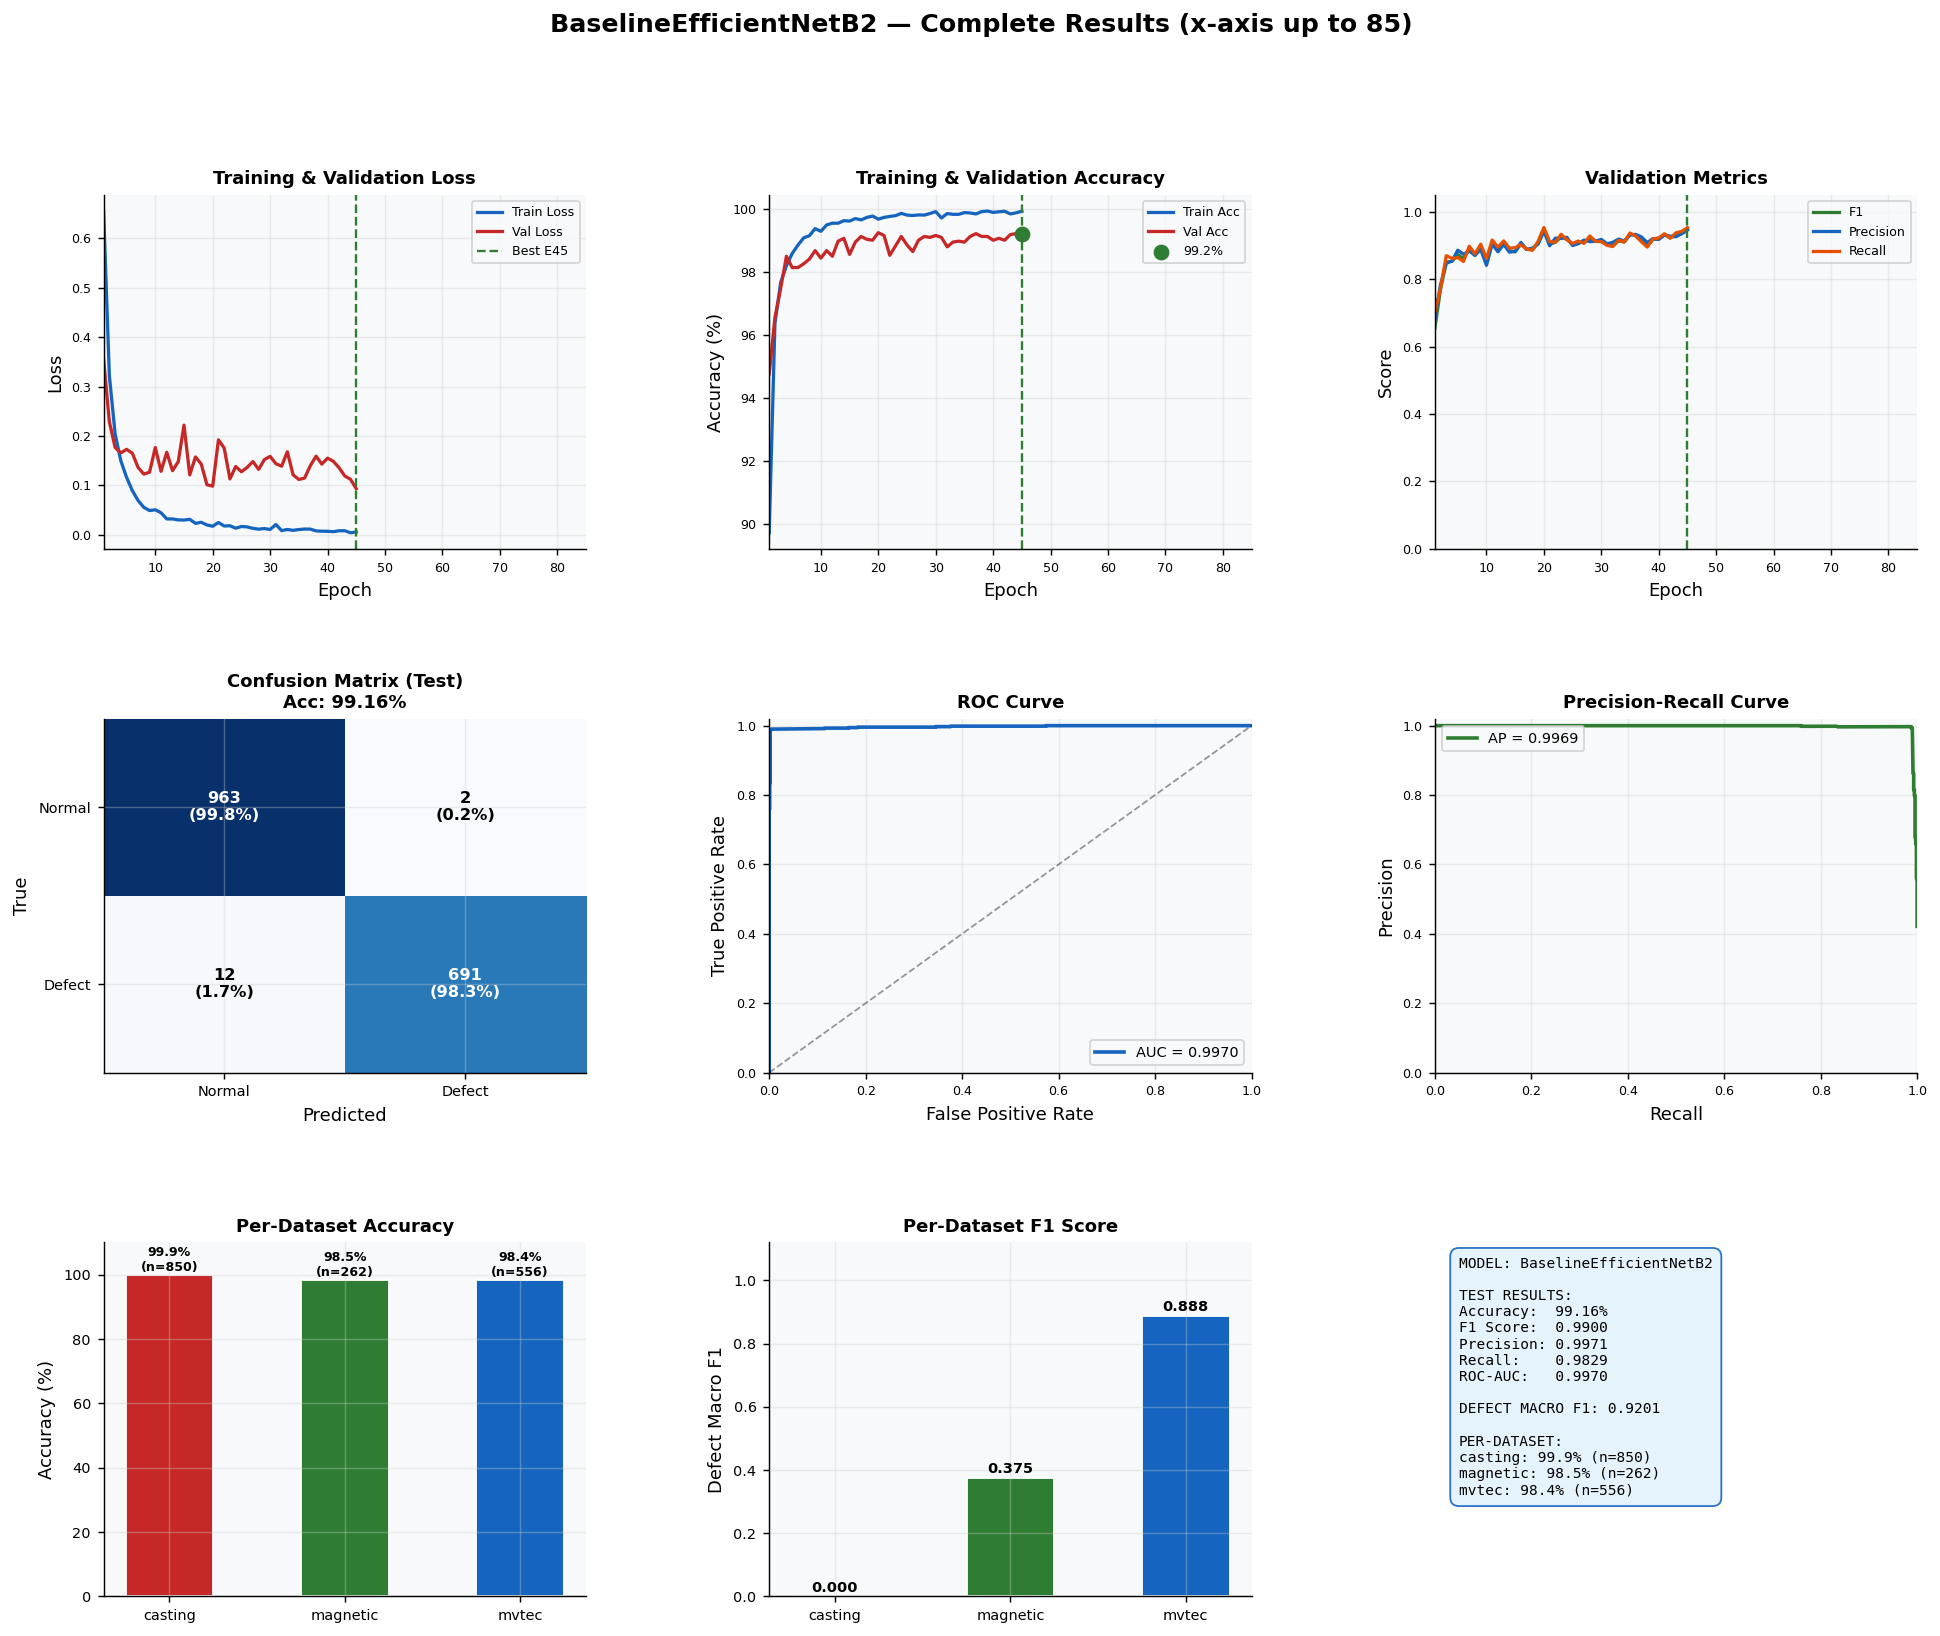

Saved: complete_results_85.png


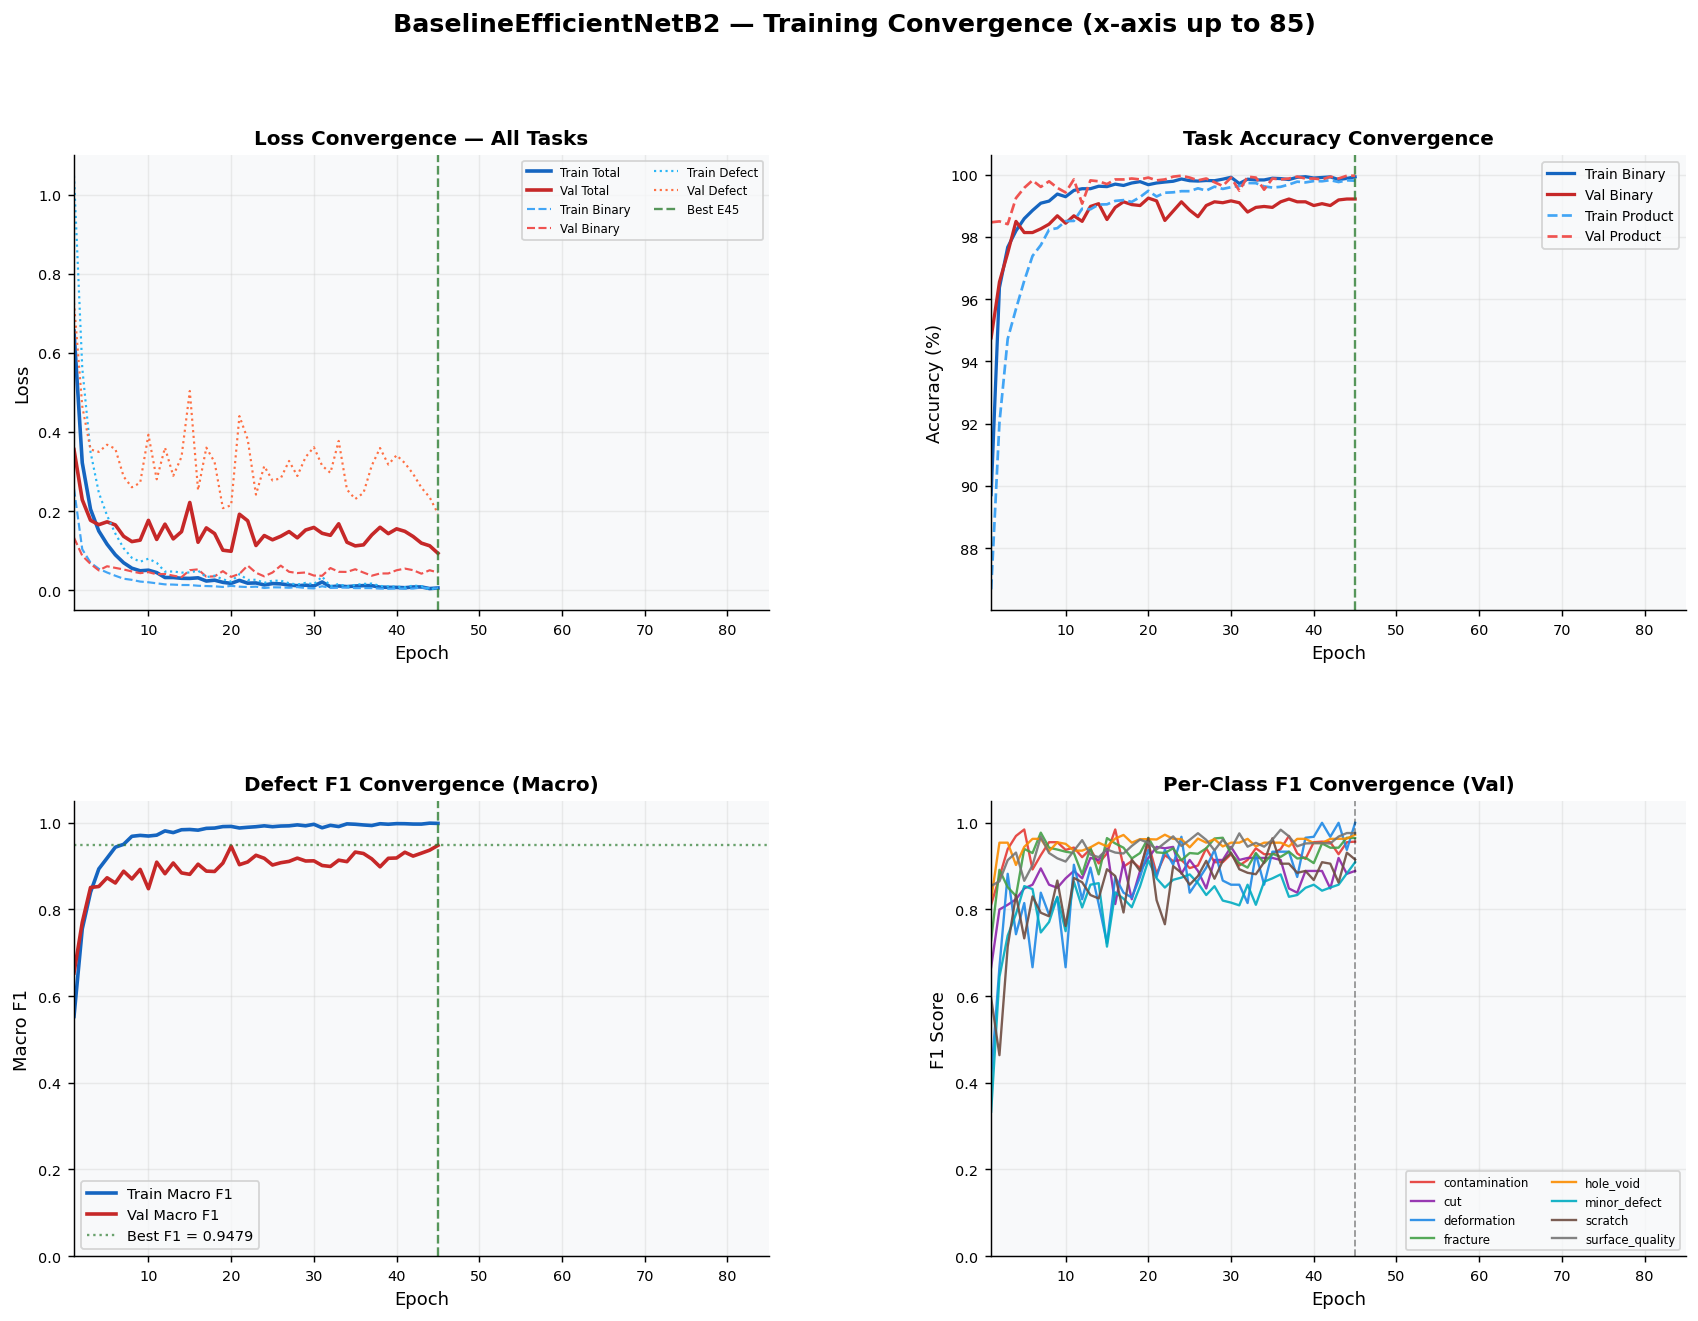

Saved: training_convergence_85.png


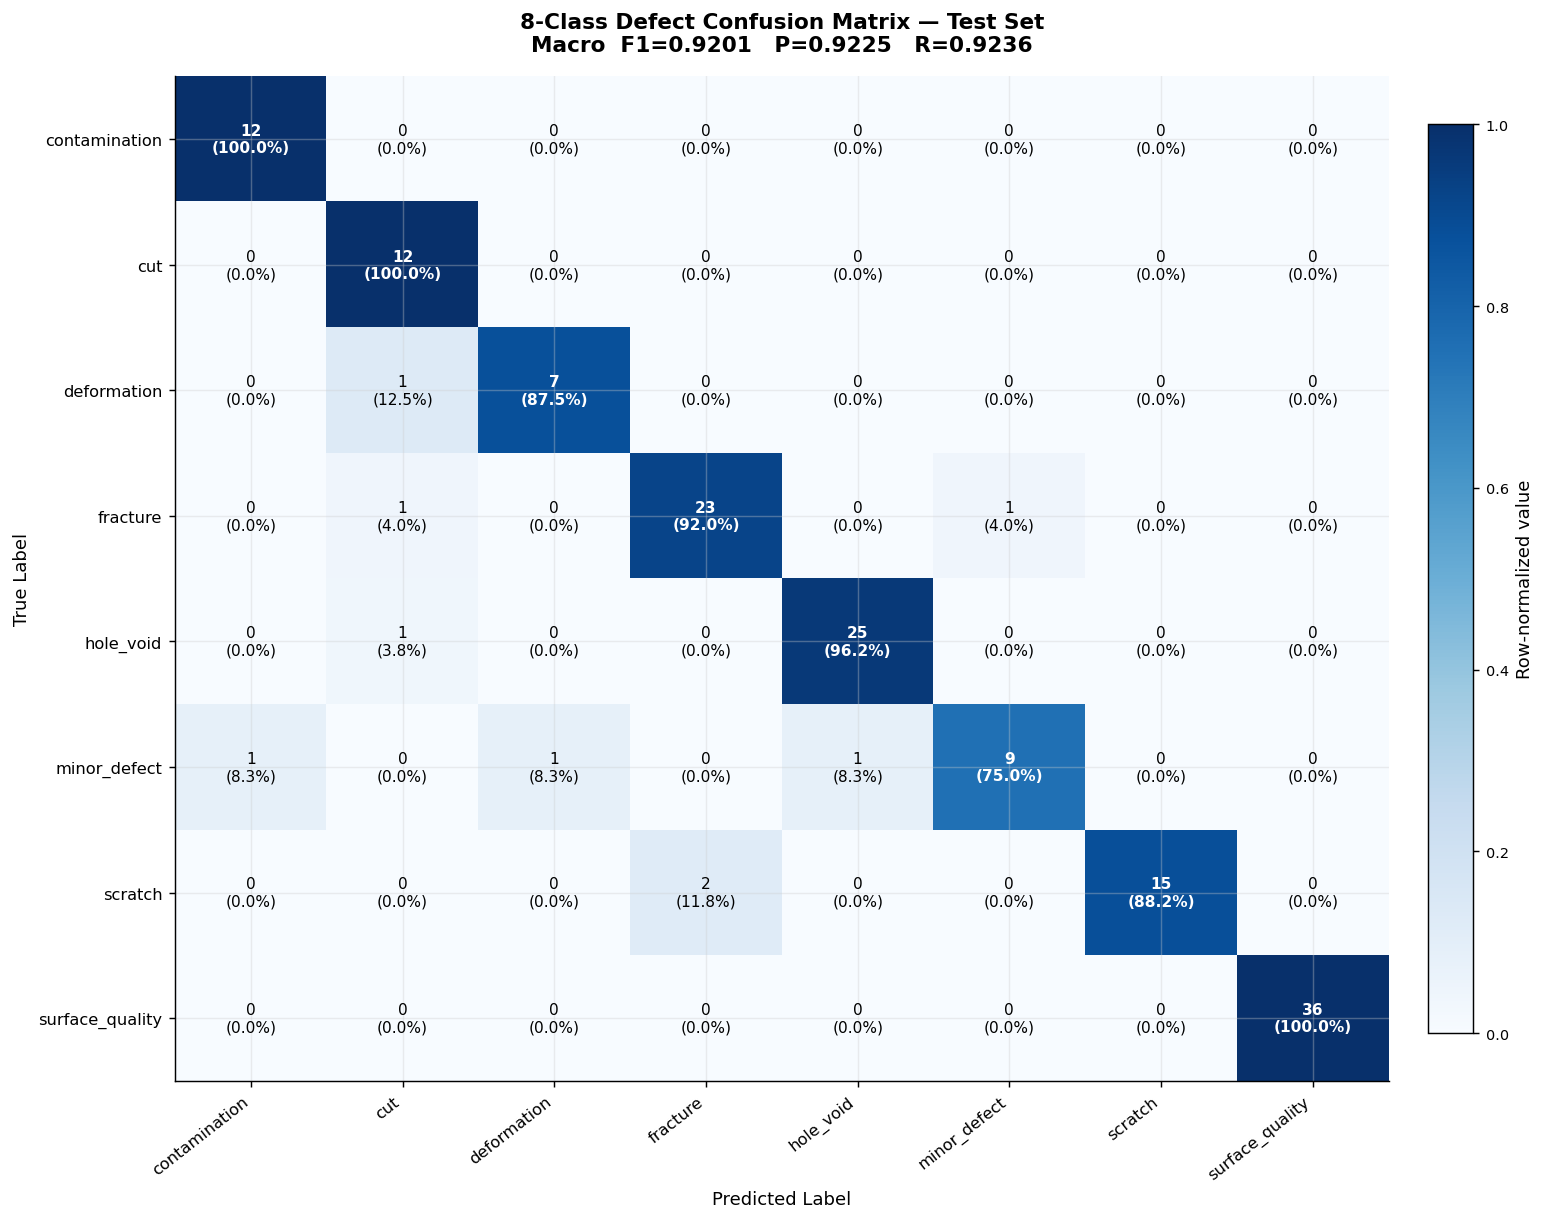

Saved: defect_confusion_matrix_85.png


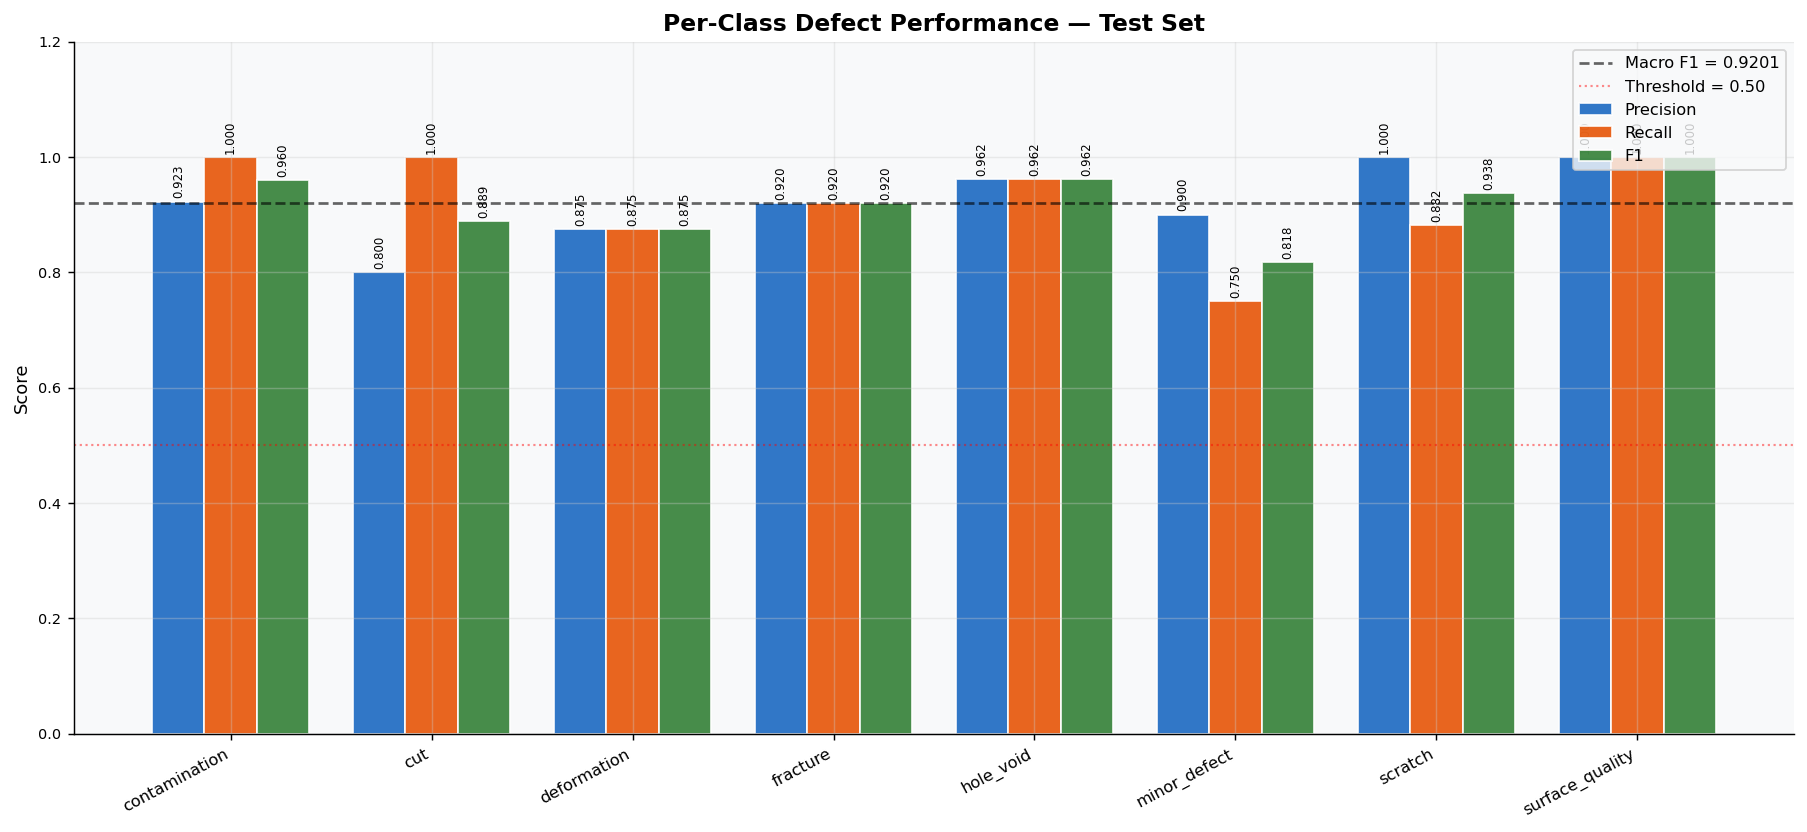

Saved: per_class_performance_85.png


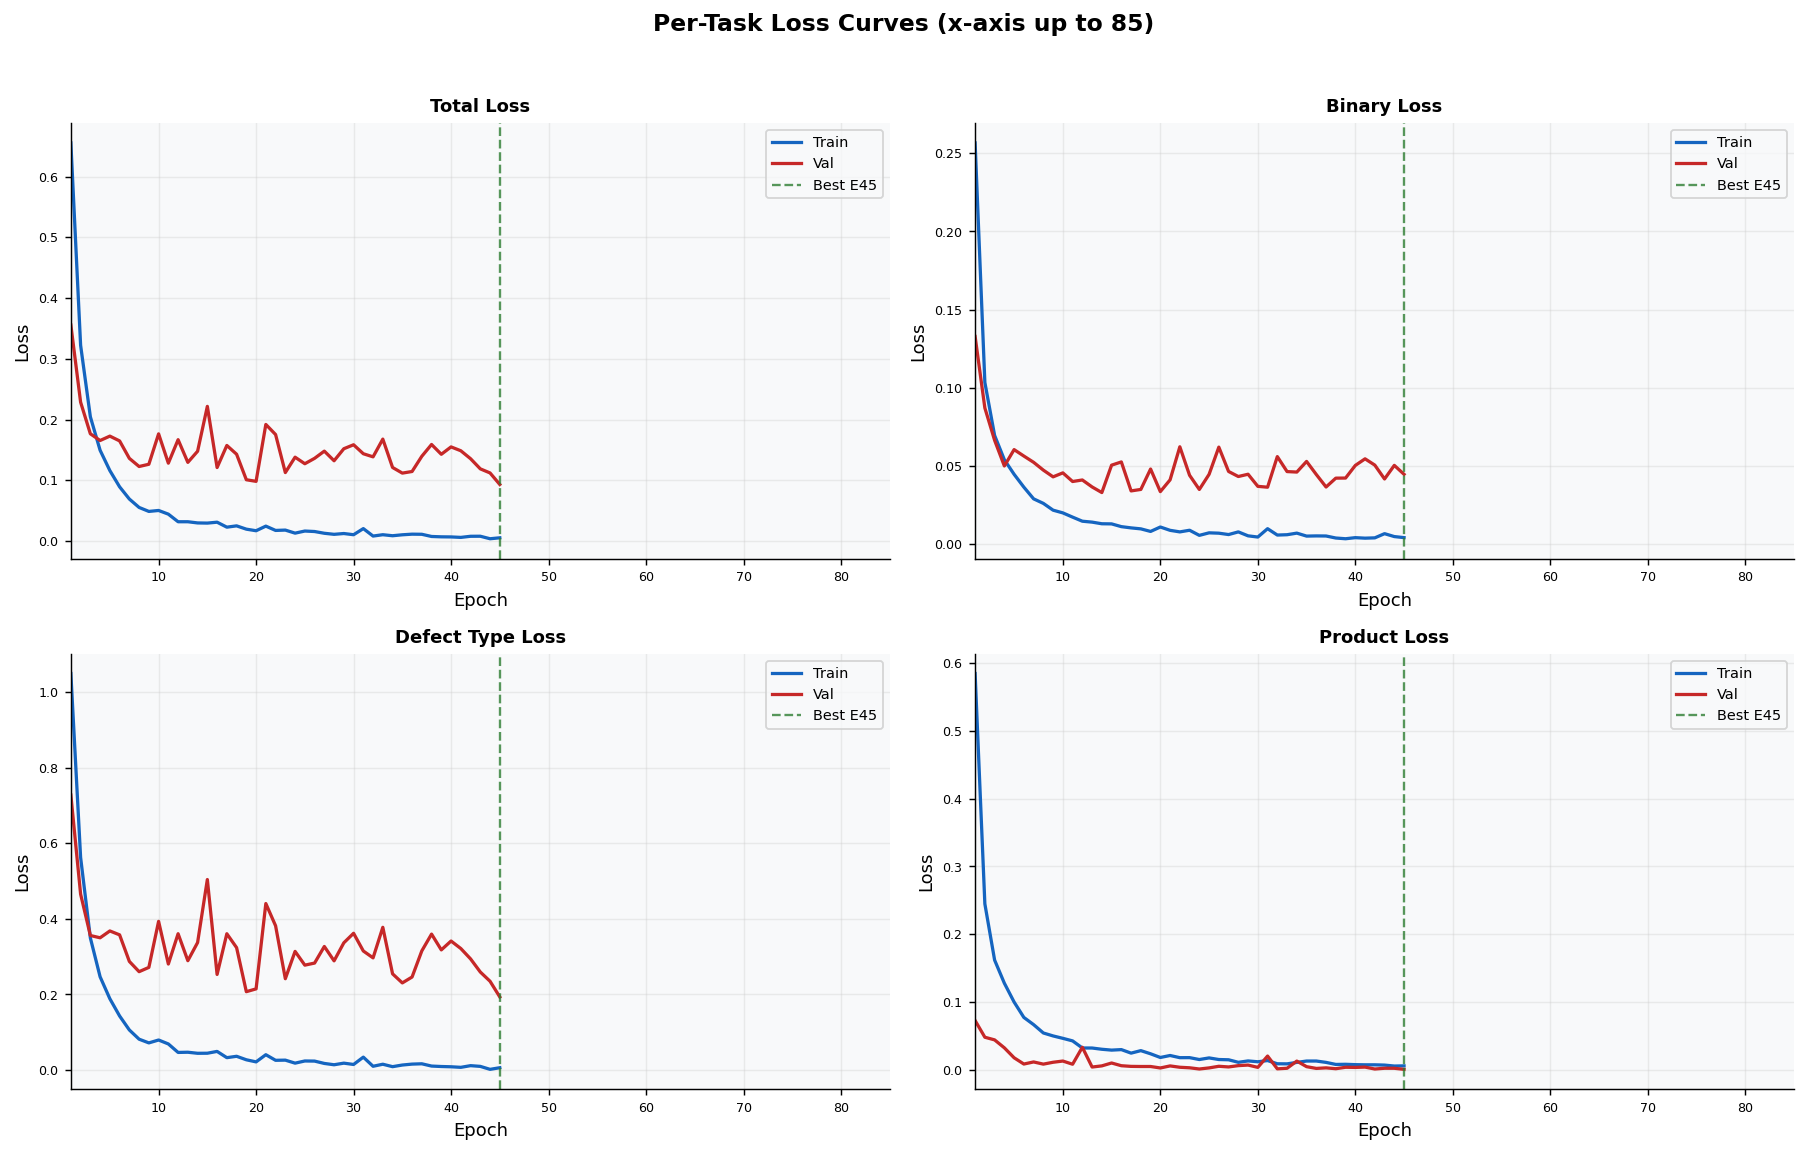

Saved: per_task_losses_85.png
  All graphs generated (x-axis up to 85):
  complete_results_85.png                  270 KB
  training_convergence_85.png              292 KB
  defect_confusion_matrix_85.png           148 KB
  per_class_performance_85.png             93 KB
  per_task_losses_85.png                   167 KB


In [12]:
# Single cell to (re)draw all figures with x-axis extended to 85 epochs.
# Safe: handles missing keys, shorter histories, and missing test_results without errors.

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from pathlib import Path

# --- Config (adjust if needed) ---
CKPT_PATH = "baseline_results/models/BaselineEfficientNetB2_best.pth"
OUT_FILES = {
    "complete": "complete_results_85.png",
    "convergence": "training_convergence_85.png",
    "defect_cm": "defect_confusion_matrix_85.png",
    "per_class": "per_class_performance_85.png",
    "per_task": "per_task_losses_85.png",
}
SEMANTIC_GROUPS = [
    "contamination", "cut", "deformation", "fracture",
    "hole_void", "minor_defect", "scratch", "surface_quality",
]
# Colors (kept from original)
C_TRAIN = "#1565C0"; C_VAL = "#C62828"; C_BEST = "#2E7D32"
C_F1 = "#2E7D32"; C_PREC = "#1565C0"; C_REC = "#E65100"
DATASET_COLORS = {"mvtec":"#1565C0","casting":"#C62828","magnetic":"#2E7D32","unknown":"#757575"}
CLASS_COLORS = ["#E53935","#8E24AA","#1E88E5","#43A047","#FB8C00","#00ACC1","#6D4C41","#757575"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.color": "#CCCCCC",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

# --- Load checkpoint safely ---
try:
    ckpt = torch.load(CKPT_PATH, map_location="cpu")
except Exception as e:
    raise RuntimeError(f"Failed to load checkpoint at '{CKPT_PATH}': {e}")

history = ckpt.get("history", {})
test_res = ckpt.get("test_results", {})

# Ensure per-class arrays are numpy arrays if present
for key in ("val_per_class_f1", "val_per_class_p", "val_per_class_r"):
    if key in history and len(history[key]):
        history[key] = np.array(history[key], dtype=float)

# Epoch handling: we will display x-axis from 1..85
EPOCH_MAX = 85
# If history contains an epoch array, use it for plotting points; otherwise infer from lengths.
hist_epochs = np.array(history.get("epoch", []), dtype=int) if "epoch" in history else np.arange(1, max(2, EPOCH_MAX+1))
# For plotting lines, use the available epoch arrays per-series; set xlim to [1, EPOCH_MAX]
def safe_get_series(name):
    """Return (x, y) for plotting. If missing, return ([],[])."""
    y = history.get(name, None)
    if y is None:
        return np.array([]), np.array([])
    y = np.asarray(y)
    # If history has explicit epoch array and lengths match, use it; else use 1..len(y)
    if len(hist_epochs) == len(y):
        return hist_epochs, y
    else:
        return np.arange(1, len(y)+1), y

# Find best epoch index for vertical markers if possible
scores = history.get("val_score", [])
epochs_arr = history.get("epoch", [])
if len(scores) and len(epochs_arr):
    best_epoch = int(epochs_arr[int(np.argmax(scores))])
    best_idx = list(epochs_arr).index(best_epoch)
else:
    best_epoch = int(epochs_arr[-1]) if len(epochs_arr) else min(EPOCH_MAX, 1)
    best_idx = 0

# --- Figure 1: Complete Results (3x3) ---
fig = plt.figure(figsize=(18, 14))
fig.suptitle("BaselineEfficientNetB2 — Complete Results (x-axis up to 85)", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# Row 0: Loss | Accuracy | Val Metrics
ax = fig.add_subplot(gs[0, 0])
x, y = safe_get_series("train_loss"); 
if len(x): ax.plot(x, y, color=C_TRAIN, lw=1.8, label="Train Loss")
x, y = safe_get_series("val_loss");
if len(x): ax.plot(x, y, color=C_VAL, lw=1.8, label="Val Loss")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, label=f"Best E{best_epoch}")
ax.set_title("Training & Validation Loss", fontsize=10, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_xlim(1, EPOCH_MAX); ax.legend(fontsize=7); ax.tick_params(labelsize=7)

ax = fig.add_subplot(gs[0, 1])
x, y = safe_get_series("train_binary_acc"); 
if len(x): ax.plot(x, y, color=C_TRAIN, lw=1.8, label="Train Acc")
x, y = safe_get_series("val_binary_acc");
if len(x): ax.plot(x, y, color=C_VAL, lw=1.8, label="Val Acc")
# scatter best val if available
if test_res:
    try:
        ax.scatter(best_epoch, history["val_binary_acc"][best_idx], color=C_BEST, s=60, zorder=6,
                   label=f"{history['val_binary_acc'][best_idx]:.1f}%")
    except Exception:
        pass
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3)
ax.set_title("Training & Validation Accuracy", fontsize=10, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_xlim(1, EPOCH_MAX); ax.legend(fontsize=7); ax.tick_params(labelsize=7)

ax = fig.add_subplot(gs[0, 2])
x, y = safe_get_series("val_f1"); 
if len(x): ax.plot(x, y, color=C_F1, lw=1.8, label="F1")
x, y = safe_get_series("val_prec");
if len(x): ax.plot(x, y, color=C_PREC, lw=1.8, label="Precision")
x, y = safe_get_series("val_rec");
if len(x): ax.plot(x, y, color=C_REC, lw=1.8, label="Recall")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3)
ax.set_title("Validation Metrics", fontsize=10, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
ax.set_ylim(0, 1.05); ax.set_xlim(1, EPOCH_MAX); ax.legend(fontsize=7); ax.tick_params(labelsize=7)

# Row 1: Binary CM | ROC | PR (only if test_res present)
if test_res:
    ax = fig.add_subplot(gs[1, 0])
    cm = np.array(test_res.get("binary_cm", [[0,0],[0,0]]))
    rs = cm.sum(axis=1, keepdims=True).clip(1)
    cmn = cm.astype(float) / rs
    ax.imshow(cm, cmap="Blues", aspect="auto")
    labs = ["Normal", "Defect"]
    ax.set_xticks([0,1]); ax.set_xticklabels(labs, fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(labs, fontsize=8)
    for i in range(2):
        for j in range(2):
            clr = "white" if cmn[i,j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i,j]}\n({cmn[i,j]*100:.1f}%)", ha="center", va="center", fontsize=9, color=clr, fontweight="bold")
    ax.set_title(f"Confusion Matrix (Test)\nAcc: {test_res.get('binary_acc',0.):.2f}%", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    ax = fig.add_subplot(gs[1, 1])
    fpr = test_res.get("fpr", []); tpr = test_res.get("tpr", [])
    if len(fpr) and len(tpr):
        ax.plot(fpr, tpr, color=C_PREC, lw=2, label=f"AUC = {test_res.get('roc_auc',0.):.4f}")
    ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
    ax.set_title("ROC Curve", fontsize=10, fontweight="bold")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(fontsize=8, loc="lower right"); ax.tick_params(labelsize=7)

    ax = fig.add_subplot(gs[1, 2])
    pr_rec = test_res.get("pr_rec", []); pr_prec = test_res.get("pr_prec", [])
    if len(pr_rec) and len(pr_prec):
        ax.plot(pr_rec, pr_prec, color=C_F1, lw=2, label=f"AP = {test_res.get('ap',0.):.4f}")
    ax.set_title("Precision-Recall Curve", fontsize=10, fontweight="bold")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(fontsize=8); ax.tick_params(labelsize=7)

# Row 2: Per-dataset Acc | Per-dataset F1 | Info box
if test_res:
    pd_ = test_res.get("per_dataset", {})
    srcs = sorted(pd_.keys()) if pd_ else []
    ax = fig.add_subplot(gs[2, 0])
    if srcs:
        accs = [pd_[s]["binary_acc"] for s in srcs]
        ns = [pd_[s]["n"] for s in srcs]
        colors = [DATASET_COLORS.get(s,"#757575") for s in srcs]
        bars = ax.bar(srcs, accs, color=colors, width=0.5, edgecolor="white")
        for bar, a, n in zip(bars, accs, ns):
            ax.text(bar.get_x()+bar.get_width()/2, a+0.3, f"{a:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_title("Per-Dataset Accuracy", fontsize=10, fontweight="bold")
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 110); ax.tick_params(labelsize=8)

    ax = fig.add_subplot(gs[2, 1])
    if srcs:
        f1s = [pd_[s]["defect_f1"] for s in srcs]
        bars = ax.bar(srcs, f1s, color=[DATASET_COLORS.get(s,"#757575") for s in srcs], width=0.5, edgecolor="white")
        for bar, f in zip(bars, f1s):
            ax.text(bar.get_x()+bar.get_width()/2, f+0.005, f"{f:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title("Per-Dataset F1 Score", fontsize=10, fontweight="bold")
    ax.set_ylabel("Defect Macro F1"); ax.set_ylim(0,1.12); ax.tick_params(labelsize=8)

    ax = fig.add_subplot(gs[2, 2]); ax.axis("off")
    lines = [
        "MODEL: BaselineEfficientNetB2", "",
        "TEST RESULTS:",
        f"Accuracy:  {test_res.get('binary_acc',0.):.2f}%",
        f"F1 Score:  {test_res.get('binary_f1',0.):.4f}",
        f"Precision: {test_res.get('binary_prec',0.):.4f}",
        f"Recall:    {test_res.get('binary_rec',0.):.4f}",
        f"ROC-AUC:   {test_res.get('roc_auc',0.):.4f}",
        "", f"DEFECT MACRO F1: {test_res.get('defect_f1',0.):.4f}",
        "", "PER-DATASET:",
    ]
    for s, m in sorted(pd_.items()):
        lines.append(f"{s}: {m['binary_acc']:.1f}% (n={m['n']})")
    ax.text(0.05, 0.96, "\n".join(lines), transform=ax.transAxes, fontsize=8, va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#E3F2FD", edgecolor="#1565C0", alpha=0.9))

plt.savefig(OUT_FILES["complete"], dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", OUT_FILES["complete"])

# --- Figure 2: Training Convergence (4-panel) ---
fig = plt.figure(figsize=(16, 11))
fig.suptitle("BaselineEfficientNetB2 — Training Convergence (x-axis up to 85)", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# A: All losses
ax = fig.add_subplot(gs[0, 0])
for key, style in [
    ("train_loss", {"color":C_TRAIN, "lw":2.0, "label":"Train Total"}),
    ("val_loss",   {"color":C_VAL,   "lw":2.0, "label":"Val Total"}),
    ("train_binary_loss", {"color":"#42A5F5","lw":1.2,"ls":"--","label":"Train Binary"}),
    ("val_binary_loss",   {"color":"#EF5350","lw":1.2,"ls":"--","label":"Val Binary"}),
    ("train_defect_loss", {"color":"#29B6F6","lw":1.2,"ls":":","label":"Train Defect"}),
    ("val_defect_loss",   {"color":"#FF7043","lw":1.2,"ls":":","label":"Val Defect"}),
]:
    x, y = safe_get_series(key)
    if len(x): ax.plot(x, y, **style)
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, alpha=0.8, label=f"Best E{best_epoch}")
ax.set_title("Loss Convergence — All Tasks", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_xlim(1, EPOCH_MAX)
ax.legend(fontsize=6.5, ncol=2); ax.tick_params(labelsize=8)

# B: Task accuracies
ax = fig.add_subplot(gs[0, 1])
for key, kwargs in [
    ("train_binary_acc", {"color":C_TRAIN,"lw":1.8,"label":"Train Binary"}),
    ("val_binary_acc",   {"color":C_VAL,"lw":1.8,"label":"Val Binary"}),
    ("train_product_acc",{"color":"#42A5F5","lw":1.5,"ls":"--","label":"Train Product"}),
    ("val_product_acc",  {"color":"#EF5350","lw":1.5,"ls":"--","label":"Val Product"}),
]:
    x, y = safe_get_series(key)
    if len(x): ax.plot(x, y, **kwargs)
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, alpha=0.8)
ax.set_title("Task Accuracy Convergence", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.set_xlim(1, EPOCH_MAX)
ax.legend(fontsize=7.5); ax.tick_params(labelsize=8)

# C: Macro defect F1
ax = fig.add_subplot(gs[1, 0])
x, y = safe_get_series("train_f1"); 
if len(x): ax.plot(x, y, color=C_TRAIN, lw=2.0, label="Train Macro F1")
x, y = safe_get_series("val_f1");
if len(x): ax.plot(x, y, color=C_VAL, lw=2.0, label="Val Macro F1")
best_f1 = float(np.max(history.get("val_f1", [0.])))
ax.axhline(best_f1, color=C_BEST, ls=":", lw=1.3, alpha=0.7, label=f"Best F1 = {best_f1:.4f}")
ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, alpha=0.8)
ax.set_title("Defect F1 Convergence (Macro)", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Macro F1"); ax.set_ylim(0, 1.05); ax.set_xlim(1, EPOCH_MAX)
ax.legend(fontsize=8); ax.tick_params(labelsize=8)

# D: Per-class F1 convergence
ax = fig.add_subplot(gs[1, 1])
pcf1 = history.get("val_per_class_f1")
if pcf1 is not None and len(pcf1):
    pcf1 = np.asarray(pcf1)
    # pcf1 shape: (epochs, 8) or similar
    n_epochs = pcf1.shape[0]
    x_vals = hist_epochs if len(hist_epochs)==n_epochs else np.arange(1, n_epochs+1)
    for i, (cls, clr) in enumerate(zip(SEMANTIC_GROUPS, CLASS_COLORS)):
        if i < pcf1.shape[1]:
            ax.plot(x_vals, pcf1[:, i], color=clr, lw=1.3, label=cls, alpha=0.9)
    ax.axvline(best_epoch, color="black", ls="--", lw=1.0, alpha=0.4)
ax.set_title("Per-Class F1 Convergence (Val)", fontsize=11, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05); ax.set_xlim(1, EPOCH_MAX)
ax.legend(fontsize=6.5, ncol=2, loc="lower right"); ax.tick_params(labelsize=8)

plt.savefig(OUT_FILES["convergence"], dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", OUT_FILES["convergence"])

# --- Figure 3: 8-class Defect Confusion Matrix (if available) ---
if test_res and "defect_cm" in test_res:
    cm = np.array(test_res["defect_cm"])
    rs = cm.sum(axis=1, keepdims=True).clip(1)
    cm_norm = cm.astype(float) / rs
    fig, ax = plt.subplots(figsize=(12, 9.5))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Row-normalized value")
    cbar.ax.tick_params(labelsize=8)
    ax.set_xticks(range(len(SEMANTIC_GROUPS))); ax.set_yticks(range(len(SEMANTIC_GROUPS)))
    ax.set_xticklabels(SEMANTIC_GROUPS, rotation=38, ha="right", fontsize=9)
    ax.set_yticklabels(SEMANTIC_GROUPS, fontsize=9)
    for i in range(len(SEMANTIC_GROUPS)):
        for j in range(len(SEMANTIC_GROUPS)):
            raw = int(cm[i, j])
            pct = cm_norm[i, j] * 100
            clr = "white" if cm_norm[i, j] > 0.55 else "black"
            bold = "bold" if i == j else "normal"
            ax.text(j, i, f"{raw}\n({pct:.1f}%)", ha="center", va="center", fontsize=8.5, color=clr, fontweight=bold)
    df1 = test_res.get("defect_f1", 0.); dprec = test_res.get("defect_prec", 0.); drec = test_res.get("defect_rec", 0.)
    ax.set_title(f"8-Class Defect Confusion Matrix — Test Set\nMacro  F1={df1:.4f}   P={dprec:.4f}   R={drec:.4f}", fontsize=12, fontweight="bold", pad=14)
    ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(OUT_FILES["defect_cm"], dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", OUT_FILES["defect_cm"])
else:
    print("No defect confusion matrix in test_results — skipped.")

# --- Figure 4: Per-class Defect Performance (grouped bars) ---
if test_res and "per_class_f1" in test_res:
    pc_f1 = np.array(test_res["per_class_f1"])
    pc_p  = np.array(test_res["per_class_p"])
    pc_r  = np.array(test_res["per_class_r"])
    x = np.arange(len(pc_f1))
    width = 0.26
    fig, ax = plt.subplots(figsize=(14, 6.5))
    b1 = ax.bar(x - width, pc_p,  width, label="Precision", color=C_PREC, alpha=0.88, edgecolor="white")
    b2 = ax.bar(x,         pc_r,  width, label="Recall",    color=C_REC,  alpha=0.88, edgecolor="white")
    b3 = ax.bar(x + width, pc_f1, width, label="F1",        color=C_F1,   alpha=0.88, edgecolor="white")
    for bars in (b1, b2, b3):
        for bar in bars:
            h = bar.get_height()
            if h > 0.02:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.006, f"{h:.3f}", ha="center", va="bottom", fontsize=6.5, rotation=90)
    macro_f1 = test_res.get("defect_f1", 0.)
    ax.axhline(macro_f1, color="black", ls="--", lw=1.5, alpha=0.6, label=f"Macro F1 = {macro_f1:.4f}")
    ax.axhline(0.50, color="red", ls=":", lw=1.2, alpha=0.45, label="Threshold = 0.50")
    ax.set_xticks(x)
    ax.set_xticklabels(SEMANTIC_GROUPS[:len(x)], rotation=28, ha="right", fontsize=9)
    ax.set_ylabel("Score"); ax.set_ylim(0, 1.20)
    ax.set_title("Per-Class Defect Performance — Test Set", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper right"); ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.savefig(OUT_FILES["per_class"], dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", OUT_FILES["per_class"])
else:
    print("No per-class performance in test_results — skipped.")

# --- Figure 5: Per-task Loss Curves (2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Per-Task Loss Curves (x-axis up to 85)", fontsize=13, fontweight="bold")
tasks = [
    ("loss",         "Total Loss",       axes[0, 0]),
    ("binary_loss",  "Binary Loss",      axes[0, 1]),
    ("defect_loss",  "Defect Type Loss", axes[1, 0]),
    ("product_loss", "Product Loss",     axes[1, 1]),
]
for key, title, ax in tasks:
    tk, vk = f"train_{key}", f"val_{key}"
    x, y = safe_get_series(tk)
    if len(x): ax.plot(x, y, color=C_TRAIN, lw=1.8, label="Train")
    x, y = safe_get_series(vk)
    if len(x): ax.plot(x, y, color=C_VAL,   lw=1.8, label="Val")
    ax.axvline(best_epoch, color=C_BEST, ls="--", lw=1.3, alpha=0.8, label=f"Best E{best_epoch}")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_xlim(1, EPOCH_MAX)
    ax.legend(fontsize=8); ax.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_FILES["per_task"], dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", OUT_FILES["per_task"])

# --- Summary of saved files ---
print("=" * 50)
print("  All graphs generated (x-axis up to 85):")
print("=" * 50)
for name in OUT_FILES.values():
    p = Path(name)
    status = f"{p.stat().st_size // 1024} KB" if p.exists() else "NOT FOUND"
    print(f"  {name:<40} {status}")


In [3]:
"""
Baseline MobileNetV2 — identical training setup to BaselineEfficientNetB2.
Only differences vs the EfficientNet script:
  • backbone : mobilenetv2_100   (pretrained=True, num_classes=0)
  • feat dim : 1280
  • img_size : 224  (MobileNetV2 native resolution)
  • names    : BaselineMobileNetV2_*
Everything else — dataset, label helpers, losses, optimizer, scheduler,
checkpoint keys, graph data — is byte-for-byte the same.
"""

import os, sys, random, time, argparse, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─────────────────────────────────────────────────────────────────────────────
SEMANTIC_GROUPS = [
    "contamination", "cut", "deformation", "fracture",
    "hole_void", "minor_defect", "scratch", "surface_quality",
]
NUM_DEFECT_TYPES   = len(SEMANTIC_GROUPS)
DEFECT_TYPE_TO_IDX = {n: i for i, n in enumerate(SEMANTIC_GROUPS)}

DEFECT_GROUP_MAP = {
    "crack":"fracture","fracture":"fracture","faulty_imprint":"fracture",
    "hole":"hole_void","void":"hole_void","pit":"hole_void","blowhole":"hole_void",
    "scratch":"scratch","score":"scratch",
    "stain":"surface_quality","color":"surface_quality","rough":"surface_quality",
    "uneven":"surface_quality","inclusion":"surface_quality","discolor":"surface_quality",
    "pilling":"surface_quality",
    "bent":"deformation","bent_lead":"deformation","squeeze":"deformation","deformation":"deformation",
    "contamination":"contamination","glue":"contamination","oil":"contamination",
    "glue_strip":"contamination","liquid":"contamination","metal_contamination":"contamination",
    "missing":"minor_defect","misplaced":"minor_defect","flip":"minor_defect",
    "missing_hole":"minor_defect","thread":"minor_defect","cable_swap":"minor_defect",
    "combined":"minor_defect",
    "cut":"cut","hole_void":"hole_void","surface_quality":"surface_quality","minor_defect":"minor_defect",
}

TASK_WEIGHTS    = [0.35, 0.40, 0.25]
WATCH_THRESHOLD = 0.50

MVTEC_PRODUCTS = {
    "bottle","cable","capsule","carpet","grid","hazelnut","leather",
    "metal_nut","pill","screw","tile","toothbrush","transistor","wood","zipper",
}

# ─────────────────────────────────────────────────────────────────────────────
class TeeLogger:
    def __init__(self, log_path):
        self._terminal = sys.__stdout__
        self._file     = open(log_path, "w", encoding="utf-8", buffering=1)
    def write(self, msg):
        self._terminal.write(msg); self._file.write(msg)
    def flush(self):
        self._terminal.flush(); self._file.flush()
    def close(self):
        self._file.close(); sys.stdout = sys.__stdout__
    def isatty(self): return False

# ─────────────────────────────────────────────────────────────────────────────
# ★ ONLY THING DIFFERENT FROM EFFICIENTNET VERSION ★
# ─────────────────────────────────────────────────────────────────────────────
class BaselineMobileNetV2(nn.Module):
    """
    Plain MobileNetV2 from timm (pretrained, unmodified).
    Feature dimension: 1280.
    """
    def __init__(self, num_defect_types=8, num_product_types=17):
        super().__init__()
        self.backbone = timm.create_model(
            "mobilenetv2_100",
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        feat = self.backbone.num_features          # 1280

        self.binary_head  = nn.Linear(feat, 1)
        self.defect_head  = nn.Linear(feat, num_defect_types)
        self.product_head = nn.Linear(feat, num_product_types)

    def forward(self, x):
        f = self.backbone(x)
        return self.binary_head(f), self.defect_head(f), self.product_head(f)

# ─────────────────────────────────────────────────────────────────────────────
# DATASET  (identical to EfficientNet version)
# ─────────────────────────────────────────────────────────────────────────────
class DefectDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(str(row["image_path"]))
        if img is None: img = np.zeros((224,224,3), dtype=np.uint8)
        else:           img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(img)
        if self.transform: img = self.transform(img)
        return (img, int(row["binary_label"]), int(row["defect_type_label"]),
                int(row["product_type_label"]), str(row["dataset_source"]),
                str(row["image_path"]))

# ─────────────────────────────────────────────────────────────────────────────
# LABEL HELPERS  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def compute_binary(v):
    if pd.isna(v): return 0
    return 0 if str(v).strip().lower() in ("0","good","normal","ok","casting_ok") else 1

def remap_defect(raw):
    if pd.isna(raw): return -1
    s = str(raw).strip().lower()
    if s in ("good","normal","casting_ok",""): return -1
    sem = DEFECT_GROUP_MAP.get(s)
    if sem is None and s in DEFECT_TYPE_TO_IDX: sem = s
    if sem is None:
        for k, v in DEFECT_GROUP_MAP.items():
            if k in s: sem = v; break
    return -1 if sem is None else DEFECT_TYPE_TO_IDX.get(sem, -1)

def infer_dataset_source(row):
    path = str(row.get("image_path","")).lower()
    prod = str(row.get("product_type","")).lower().strip()
    for key, src in [("mvtec","mvtec"),("casting","casting"),
                     ("magnetic","magnetic"),("tile","magnetic")]:
        if key in path: return src
    if prod in MVTEC_PRODUCTS: return "mvtec"
    if "cast" in prod:         return "casting"
    if "magnet" in prod or prod.startswith("mt"): return "magnetic"
    return "unknown"

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    if "path"     in df.columns and "image_path"   not in df.columns: df = df.rename(columns={"path":"image_path"})
    if "category" in df.columns and "product_type" not in df.columns: df = df.rename(columns={"category":"product_type"})
    df["binary_label"]       = df["label"].apply(compute_binary)
    df["defect_type_label"]  = df["defect_type"].apply(remap_defect)
    df.loc[df["binary_label"]==0, "defect_type_label"] = -1
    all_products = sorted(df["product_type"].dropna().unique().tolist())
    p2i = {p:i for i,p in enumerate(all_products)}
    i2p = {i:p for i,p in enumerate(all_products)}
    df["product_type_label"] = [p2i.get(str(v),0) if not pd.isna(v) else 0 for v in df["product_type"]]
    if "dataset_source" in df.columns: pass
    elif "source" in df.columns: df["dataset_source"] = df["source"]
    else: df["dataset_source"] = df.apply(infer_dataset_source, axis=1)
    return df, all_products, p2i, i2p

# ─────────────────────────────────────────────────────────────────────────────
# STATS PRINT  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def print_dataset_stats(df, train_df, val_df, test_df, all_products):
    SEP = "="*74; total=len(df)
    n_norm=int((df["binary_label"]==0).sum()); n_def=int((df["binary_label"]==1).sum())
    print(f"\n{SEP}\n  DATASET STATISTICS\n{SEP}\n")
    print(f"  {'Total images':<32}: {total:>7,}")
    print(f"  {'Normal (good)':<32}: {n_norm:>7,}  ({100.*n_norm/total:.1f}%)")
    print(f"  {'Defective':<32}: {n_def:>7,}  ({100.*n_def/total:.1f}%)")
    print(f"\n  Splits  →  Train:{len(train_df):>6,}  |  Val:{len(val_df):>5,}  |  Test:{len(test_df):>5,}")
    for src in sorted(df["dataset_source"].unique()):
        nt=int((df["dataset_source"]==src).sum())
        ntr=int((train_df["dataset_source"]==src).sum())
        nva=int((val_df["dataset_source"]==src).sum())
        nte=int((test_df["dataset_source"]==src).sum())
        print(f"  {src:<18} {nt:>7,} {ntr:>7,} {nva:>6,} {nte:>6,}")
    print(f"\n  Defect class distribution:")
    print(f"  {'Class':<22} {'Total':>7} {'Train':>7} {'Val':>6} {'Test':>6}")
    print(f"  {'-'*52}")
    for i,name in enumerate(SEMANTIC_GROUPS):
        nt=int((df["defect_type_label"]==i).sum())
        ntr=int((train_df["defect_type_label"]==i).sum())
        nva=int((val_df["defect_type_label"]==i).sum())
        nte=int((test_df["defect_type_label"]==i).sum())
        print(f"  [{i}] {name:<20} {nt:>7,} {ntr:>7,} {nva:>6,} {nte:>6,}")
    print()

# ─────────────────────────────────────────────────────────────────────────────
# METRICS  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def compute_defect_metrics(preds, labels):
    mask=labels!=-1; z=np.zeros(NUM_DEFECT_TYPES)
    if mask.sum()==0:
        return {"f1":0.,"prec":0.,"rec":0.,
                "per_class_p":z.copy(),"per_class_r":z.copy(),"per_class_f1":z.copy()}
    p,r,f,_=precision_recall_fscore_support(labels[mask],preds[mask],
             average=None,labels=list(range(NUM_DEFECT_TYPES)),zero_division=0)
    return {"f1":float(f.mean()),"prec":float(p.mean()),"rec":float(r.mean()),
            "per_class_p":p,"per_class_r":r,"per_class_f1":f}

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer):
    model.train()
    bce=nn.BCEWithLogitsLoss(); ce=nn.CrossEntropyLoss(); tw=TASK_WEIGHTS
    total_loss=bin_loss=def_loss=prod_loss=0.
    bc=dc=pc=dt=n=0; dpreds_all=[]; dlabels_all=[]
    pbar=tqdm(loader,desc="Train",leave=False,dynamic_ncols=True)
    for imgs,bin_l,def_l,prod_l,_,_ in pbar:
        imgs=imgs.to(device); bin_l=bin_l.to(device); def_l=def_l.to(device); prod_l=prod_l.to(device)
        optimizer.zero_grad()
        bo,do,po=model(imgs); bo=bo.squeeze(1)
        bl=bce(bo,bin_l.float()); pl=ce(po,prod_l)
        dm=def_l!=-1
        dl=ce(do[dm],def_l[dm]) if dm.any() else torch.tensor(0.,device=device)
        loss=tw[0]*bl+tw[1]*dl+tw[2]*pl; loss.backward(); optimizer.step()
        bs=imgs.size(0)
        total_loss+=loss.item()*bs; bin_loss+=bl.item()*bs
        def_loss+=dl.item()*bs; prod_loss+=pl.item()*bs; n+=bs
        with torch.no_grad():
            bp=(torch.sigmoid(bo)>0.5).long(); _,dp=torch.max(do,1); _,pp=torch.max(po,1)
        bc+=(bp==bin_l).sum().item(); pc+=(pp==prod_l).sum().item()
        if dm.any(): dc+=(dp[dm]==def_l[dm]).sum().item(); dt+=dm.sum().item()
        dpreds_all.append(dp.cpu().numpy()); dlabels_all.append(def_l.cpu().numpy())
        pbar.set_postfix({"loss":f"{total_loss/n:.3f}","bin":f"{100.*bc/n:.1f}%",
                          "def":f"{100.*dc/dt:.1f}%" if dt else "n/a"})
    d=max(n,1); dtd=max(dt,1)
    met=compute_defect_metrics(np.concatenate(dpreds_all),np.concatenate(dlabels_all))
    return {"loss":total_loss/d,"binary_loss":bin_loss/d,"defect_loss":def_loss/d,
            "product_loss":prod_loss/d,"binary_acc":100.*bc/d,"defect_acc":100.*dc/dtd,
            "product_acc":100.*pc/d,**met}

# ─────────────────────────────────────────────────────────────────────────────
# VALIDATE  (identical)
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader):
    model.eval()
    bce=nn.BCEWithLogitsLoss(); ce=nn.CrossEntropyLoss(); tw=TASK_WEIGHTS
    total_loss=bin_loss=def_loss=prod_loss=0.
    bc=dc=pc=dt=n=0; dpreds_all=[]; dlabels_all=[]
    for imgs,bin_l,def_l,prod_l,_,_ in tqdm(loader,desc="Val  ",leave=False,dynamic_ncols=True):
        imgs=imgs.to(device); bin_l=bin_l.to(device); def_l=def_l.to(device); prod_l=prod_l.to(device)
        bo,do,po=model(imgs); bo=bo.squeeze(1)
        bl=bce(bo,bin_l.float()); pl=ce(po,prod_l)
        dm=def_l!=-1
        dl=ce(do[dm],def_l[dm]) if dm.any() else torch.tensor(0.,device=device)
        loss=tw[0]*bl+tw[1]*dl+tw[2]*pl
        bs=imgs.size(0)
        total_loss+=loss.item()*bs; bin_loss+=bl.item()*bs
        def_loss+=dl.item()*bs; prod_loss+=pl.item()*bs; n+=bs
        bp=(torch.sigmoid(bo)>0.5).long(); _,dp=torch.max(do,1); _,pp=torch.max(po,1)
        bc+=(bp==bin_l).sum().item(); pc+=(pp==prod_l).sum().item()
        if dm.any(): dc+=(dp[dm]==def_l[dm]).sum().item(); dt+=dm.sum().item()
        dpreds_all.append(dp.cpu().numpy()); dlabels_all.append(def_l.cpu().numpy())
    d=max(n,1); dtd=max(dt,1)
    met=compute_defect_metrics(np.concatenate(dpreds_all),np.concatenate(dlabels_all))
    return {"loss":total_loss/d,"binary_loss":bin_loss/d,"defect_loss":def_loss/d,
            "product_loss":prod_loss/d,"binary_acc":100.*bc/d,"defect_acc":100.*dc/dtd,
            "product_acc":100.*pc/d,**met}

# ─────────────────────────────────────────────────────────────────────────────
# TEST EVAL  (identical)
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_test(model, loader):
    model.eval()
    bin_scores_l=[]; bin_preds_l=[]; bin_labels_l=[]
    def_preds_l=[]; def_labels_l=[]
    prod_preds_l=[]; prod_labels_l=[]; sources_l=[]
    bc=dc=pc=dt=n=0
    for imgs,bin_l,def_l,prod_l,src,_ in tqdm(loader,desc="Test ",leave=False,dynamic_ncols=True):
        imgs=imgs.to(device); bin_l_d=bin_l.to(device); def_l_d=def_l.to(device); prod_l_d=prod_l.to(device)
        bo,do,po=model(imgs); bo=bo.squeeze(1)
        scores=torch.sigmoid(bo).cpu().numpy(); bpreds=(scores>0.5).astype(int)
        _,dpreds=torch.max(do,1); _,ppreds=torch.max(po,1)
        dpreds_np=dpreds.cpu().numpy(); ppreds_np=ppreds.cpu().numpy()
        bin_scores_l.extend(scores.tolist()); bin_preds_l.extend(bpreds.tolist())
        bin_labels_l.extend(bin_l.numpy().tolist()); def_preds_l.extend(dpreds_np.tolist())
        def_labels_l.extend(def_l.numpy().tolist()); prod_preds_l.extend(ppreds_np.tolist())
        prod_labels_l.extend(prod_l.numpy().tolist()); sources_l.extend(list(src))
        bs=imgs.size(0); n+=bs
        bc+=int((bpreds==bin_l.numpy()).sum())
        pc+=int((ppreds==prod_l_d).sum().item())
        dm=def_l_d!=-1
        if dm.any(): dc+=int((dpreds[dm]==def_l_d[dm]).sum().item()); dt+=int(dm.sum().item())
    bin_scores=np.array(bin_scores_l); bin_preds=np.array(bin_preds_l); bin_labels=np.array(bin_labels_l)
    def_preds=np.array(def_preds_l); def_labels=np.array(def_labels_l)
    prod_preds=np.array(prod_preds_l); prod_labels=np.array(prod_labels_l); sources=np.array(sources_l)
    bin_acc=100.*bc/max(n,1)
    bin_cm=confusion_matrix(bin_labels,bin_preds,labels=[0,1])
    fpr,tpr,_=roc_curve(bin_labels,bin_scores); roc_auc=float(auc(fpr,tpr))
    p_pr,r_pr,_=precision_recall_curve(bin_labels,bin_scores)
    ap=float(average_precision_score(bin_labels,bin_scores))
    bin_p,bin_r,bin_f1,_=precision_recall_fscore_support(bin_labels,bin_preds,average="binary",zero_division=0)
    def_mask=def_labels!=-1
    def_cm=confusion_matrix(def_labels[def_mask],def_preds[def_mask],labels=list(range(NUM_DEFECT_TYPES)))
    def_met=compute_defect_metrics(def_preds,def_labels)
    prod_cm=confusion_matrix(prod_labels,prod_preds); prod_acc=100.*pc/max(n,1)
    per_dataset={}
    for src in sorted(set(sources_l)):
        mask=sources==src
        if mask.sum()==0: continue
        s_sc=bin_scores[mask]; s_bl=bin_labels[mask]; s_bp=bin_preds[mask]
        s_dl=def_labels[mask]; s_dp=def_preds[mask]
        s_acc=float(np.mean(s_bp==s_bl))*100.; s_met=compute_defect_metrics(s_dp,s_dl)
        s_bp2,s_br,s_bf1,_=precision_recall_fscore_support(s_bl,s_bp,average="binary",zero_division=0)
        try: s_fpr,s_tpr,_=roc_curve(s_bl,s_sc); s_auc=float(auc(s_fpr,s_tpr)); s_fpr_l,s_tpr_l=s_fpr.tolist(),s_tpr.tolist()
        except ValueError: s_auc=0.; s_fpr_l=s_tpr_l=[]
        try: s_ppr,s_rpr,_=precision_recall_curve(s_bl,s_sc); s_ap=float(average_precision_score(s_bl,s_sc)); s_ppr_l,s_rpr_l=s_ppr.tolist(),s_rpr.tolist()
        except ValueError: s_ap=0.; s_ppr_l=s_rpr_l=[]
        per_dataset[src]={"n":int(mask.sum()),"binary_acc":float(s_acc),"binary_f1":float(s_bf1),
            "binary_prec":float(s_bp2),"binary_rec":float(s_br),"defect_f1":float(s_met["f1"]),
            "defect_prec":float(s_met["prec"]),"defect_rec":float(s_met["rec"]),
            "per_class_f1":[float(x) for x in s_met["per_class_f1"]],
            "per_class_p":[float(x) for x in s_met["per_class_p"]],
            "per_class_r":[float(x) for x in s_met["per_class_r"]],
            "roc_auc":s_auc,"ap":s_ap,"fpr":s_fpr_l,"tpr":s_tpr_l,"pr_prec":s_ppr_l,"pr_rec":s_rpr_l}
    return {"bin_scores":bin_scores.tolist(),"bin_preds":bin_preds.tolist(),"bin_labels":bin_labels.tolist(),
            "def_preds":def_preds.tolist(),"def_labels":def_labels.tolist(),
            "prod_preds":prod_preds.tolist(),"prod_labels":prod_labels.tolist(),"sources":sources.tolist(),
            "binary_cm":bin_cm.tolist(),"defect_cm":def_cm.tolist(),"product_cm":prod_cm.tolist(),
            "fpr":fpr.tolist(),"tpr":tpr.tolist(),"roc_auc":roc_auc,
            "pr_prec":p_pr.tolist(),"pr_rec":r_pr.tolist(),"ap":ap,
            "binary_acc":float(bin_acc),"binary_f1":float(bin_f1),"binary_prec":float(bin_p),"binary_rec":float(bin_r),
            "defect_f1":float(def_met["f1"]),"defect_prec":float(def_met["prec"]),"defect_rec":float(def_met["rec"]),
            "per_class_f1":[float(x) for x in def_met["per_class_f1"]],
            "per_class_p":[float(x) for x in def_met["per_class_p"]],
            "per_class_r":[float(x) for x in def_met["per_class_r"]],
            "product_acc":float(prod_acc),"per_dataset":per_dataset,"n_total":int(n)}

# ─────────────────────────────────────────────────────────────────────────────
# EPOCH PRINT  (identical format)
# ─────────────────────────────────────────────────────────────────────────────
def print_epoch_summary(epoch, epochs, lr, train_m, val_m, prev_f1, is_best, best_f1):
    tw_str="["+"  ".join(f"{w:.2f}" for w in TASK_WEIGHTS)+"]"
    print(f"\nEpoch [{epoch:>3}/{epochs}]  LR={lr:.2e}  TaskW={tw_str}")
    print()
    print(f"  Train → Bin={train_m['binary_acc']:.1f}%  Def={train_m['defect_acc']:.1f}%  F1={train_m['f1']:.3f}  Prod={train_m['product_acc']:.1f}%")
    print(f"  Val   → Bin={val_m['binary_acc']:.1f}%  Def={val_m['defect_acc']:.1f}%  F1={val_m['f1']:.3f}  Prod={val_m['product_acc']:.1f}%")
    cur_f1=val_m["per_class_f1"]; W=22; SEP="─"*(W+34)
    print(); print(f"  {'Class':<{W}}  {'P':>7} {'R':>7} {'F1':>7}  Trend"); print(f"  {SEP}")
    for i,cls in enumerate(SEMANTIC_GROUPS):
        delta=cur_f1[i]-prev_f1[i]
        tr="→" if abs(delta)<0.005 else ("↑" if delta>0 else "↓")
        watch="  ◄ WATCH" if cur_f1[i]<WATCH_THRESHOLD else ""
        print(f"  {cls:<{W}}  {val_m['per_class_p'][i]:>7.3f} {val_m['per_class_r'][i]:>7.3f} {cur_f1[i]:>7.3f}  {tr}{watch}")
    print(f"  {SEP}")
    print(f"  {'MACRO':<{W}}  {val_m['prec']:>7.3f} {val_m['rec']:>7.3f} {val_m['f1']:>7.3f}")
    if is_best:
        print(f"\n  ✅ NEW BEST  defect_f1={val_m['f1']:.4f} → saved BaselineMobileNetV2_best.pth")
    else:
        print(f"\n  (no improvement  best_f1={best_f1:.4f})")

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--csv",      default="/home/sufi/merged_dataset_metadata_augmented.csv")
    parser.add_argument("--epochs",   type=int,   default=100)
    parser.add_argument("--batch",    type=int,   default=32)
    parser.add_argument("--workers",  type=int,   default=4)
    parser.add_argument("--lr",       type=float, default=1e-4)
    parser.add_argument("--patience", type=int,   default=40)
    parser.add_argument("--img_size", type=int,   default=224)   # ← 224, not 260
    parser.add_argument("--out_dir",  default="baseline_results")
    args, _ = parser.parse_known_args()

    OUT_DIR   = Path(args.out_dir)
    MODEL_DIR = OUT_DIR / "models"
    OUT_DIR.mkdir(parents=True, exist_ok=True); MODEL_DIR.mkdir(parents=True, exist_ok=True)

    ts       = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = OUT_DIR / f"BaselineMobileNetV2_{ts}.log"
    sys.stdout = TeeLogger(str(log_path))
    print(f"\nDevice  : {device}\nLog     : {log_path}")

    df, all_products, p2i, i2p = load_data(args.csv)
    n_products = len(all_products)
    train_df = df[df["split"]=="train"].reset_index(drop=True)
    val_df   = df[df["split"]=="val"].reset_index(drop=True)
    test_df  = df[df["split"]=="test"].reset_index(drop=True)
    print_dataset_stats(df, train_df, val_df, test_df, all_products)

    IMG = args.img_size
    train_tf = transforms.Compose([
        transforms.Resize((IMG, IMG)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((IMG, IMG)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    train_loader = DataLoader(DefectDataset(train_df, train_tf), batch_size=args.batch,
                              shuffle=True,  num_workers=args.workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(DefectDataset(val_df,   eval_tf),  batch_size=args.batch,
                              shuffle=False, num_workers=args.workers, pin_memory=True)
    test_loader  = DataLoader(DefectDataset(test_df,  eval_tf),  batch_size=args.batch,
                              shuffle=False, num_workers=args.workers, pin_memory=True)

    model = BaselineMobileNetV2(NUM_DEFECT_TYPES, n_products).to(device)
    total_params = sum(p.numel() for p in model.parameters())

    optimizer = optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=args.epochs, eta_min=1e-6)

    SEP = "="*74
    print(f"\n{SEP}\n  TRAINING CONFIG — Baseline MobileNetV2\n{SEP}\n")
    print(f"  Backbone     : timm mobilenetv2_100  (pretrained=True, UNMODIFIED)")
    print(f"  Total params : {total_params/1e6:.3f}M")
    print(f"  Feature dim  : {model.backbone.num_features}")
    print(f"  Image size   : {IMG}×{IMG}")
    print(f"  Batch size   : {args.batch}  |  Epochs: {args.epochs}  |  Patience: {args.patience}")
    print(f"  Optimizer    : AdamW  (single LR group, lr={args.lr:.1e}, wd=1e-4)")
    print(f"  Scheduler    : CosineAnnealingLR  (T_max={args.epochs}, eta_min=1e-6)")
    print(f"  Augmentation : RandomHorizontalFlip only")
    print(f"  Task weights : bin={TASK_WEIGHTS[0]}  defect={TASK_WEIGHTS[1]}  prod={TASK_WEIGHTS[2]}")
    print(f"  Loss         : BCEWithLogitsLoss + CrossEntropyLoss")
    print(f"  Extras       : NONE  (no EMA, no CutMix, no WeightedSampler)\n")

    history = {
        "epoch":[],"train_loss":[],"val_loss":[],
        "train_binary_loss":[],"val_binary_loss":[],
        "train_defect_loss":[],"val_defect_loss":[],
        "train_product_loss":[],"val_product_loss":[],
        "train_binary_acc":[],"val_binary_acc":[],
        "train_defect_acc":[],"val_defect_acc":[],
        "train_product_acc":[],"val_product_acc":[],
        "train_f1":[],"val_f1":[],"train_prec":[],"val_prec":[],"train_rec":[],"val_rec":[],
        "val_per_class_f1":[],"val_per_class_p":[],"val_per_class_r":[],
        "lr":[],"val_score":[],
    }

    best_score=0.; best_f1=0.; best_epoch=0; pat_count=0
    prev_f1=[0.]*NUM_DEFECT_TYPES
    best_path = MODEL_DIR / "BaselineMobileNetV2_best.pth"
    start_t   = time.time()

    print(f"{SEP}\n  TRAINING\n{SEP}")

    for epoch in range(1, args.epochs+1):
        lr_now = optimizer.param_groups[0]["lr"]
        train_m = train_epoch(model, train_loader, optimizer)
        val_m   = validate(model, val_loader)
        scheduler.step()

        val_score = 0.30*val_m["binary_acc"]/100. + 0.50*val_m["f1"] + 0.20*val_m["product_acc"]/100.

        history["epoch"].append(epoch)
        for split, m in [("train",train_m),("val",val_m)]:
            for key in ("loss","binary_loss","defect_loss","product_loss",
                        "binary_acc","defect_acc","product_acc","f1","prec","rec"):
                history[f"{split}_{key}"].append(float(m[key]))
        for key in ("per_class_f1","per_class_p","per_class_r"):
            history[f"val_{key}"].append([float(x) for x in val_m[key]])
        history["lr"].append(lr_now); history["val_score"].append(float(val_score))

        is_best = val_score > best_score
        print_epoch_summary(epoch, args.epochs, lr_now, train_m, val_m, prev_f1, is_best, best_f1)
        prev_f1 = [float(x) for x in val_m["per_class_f1"]]

        if is_best:
            best_score=val_score; best_f1=val_m["f1"]; best_epoch=epoch; pat_count=0
            torch.save({
                "epoch":epoch,"model_state_dict":model.state_dict(),
                "optimizer_state_dict":optimizer.state_dict(),
                "scheduler_state_dict":scheduler.state_dict(),
                "model_name":"BaselineMobileNetV2","backbone":"mobilenetv2_100",
                "backbone_source":"timm","pretrained":True,"backbone_modified":False,
                "num_defect_types":NUM_DEFECT_TYPES,"num_product_types":n_products,
                "img_size":IMG,"feat_dim":model.backbone.num_features,
                "total_params":total_params,"val_score":float(best_score),"val_f1":float(best_f1),
                "history":history,"class_names":SEMANTIC_GROUPS,
                "defect_type_to_idx":DEFECT_TYPE_TO_IDX,"product_names":all_products,
                "product_type_to_idx":p2i,"idx_to_product_type":i2p,
                "config":vars(args),"task_weights":TASK_WEIGHTS,"seed":SEED,
            }, best_path)
        else:
            pat_count+=1
            if pat_count>=args.patience:
                print(f"\n  ⚠️  Early stopping at epoch {epoch}  (best: E{best_epoch}  F1={best_f1:.4f})")
                break

    total_min = (time.time()-start_t)/60.

    print(f"\n{SEP}\n  TEST SET EVALUATION  (best checkpoint: epoch {best_epoch})\n{SEP}\n")
    best_ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(best_ckpt["model_state_dict"])
    test_res = evaluate_test(model, test_loader)

    print(f"  Binary  →  Acc={test_res['binary_acc']:.2f}%  F1={test_res['binary_f1']:.4f}"
          f"  ROC-AUC={test_res['roc_auc']:.4f}  AP={test_res['ap']:.4f}")
    print(f"  Defect  →  Macro F1={test_res['defect_f1']:.4f}"
          f"  P={test_res['defect_prec']:.4f}  R={test_res['defect_rec']:.4f}")
    print(f"  Product →  Acc={test_res['product_acc']:.2f}%")

    W=22; S2="─"*(W+28)
    print(f"\n  8-class Defect — Test Set:")
    print(f"  {'Class':<{W}}  {'P':>7} {'R':>7} {'F1':>7}"); print(f"  {S2}")
    for i,cls in enumerate(SEMANTIC_GROUPS):
        print(f"  {cls:<{W}}  {test_res['per_class_p'][i]:>7.3f}"
              f" {test_res['per_class_r'][i]:>7.3f} {test_res['per_class_f1'][i]:>7.3f}")
    print(f"  {S2}")
    print(f"  {'MACRO':<{W}}  {test_res['defect_prec']:>7.3f}"
          f" {test_res['defect_rec']:>7.3f} {test_res['defect_f1']:>7.3f}")

    best_ckpt["test_results"] = test_res
    torch.save(best_ckpt, best_path)

    print(f"\n{SEP}\n  DONE\n{SEP}\n")
    print(f"  Training time : {total_min:.1f} min")
    print(f"  Best epoch    : {best_epoch}  |  Best val F1 : {best_f1:.4f}")
    print(f"  Test bin acc  : {test_res['binary_acc']:.2f}%")
    print(f"  Test ROC-AUC  : {test_res['roc_auc']:.4f}")
    print(f"  Test defect F1: {test_res['defect_f1']:.4f}")
    print(f"\n  Checkpoint    : {best_path}")
    print(f"  Log           : {log_path}")

    if isinstance(sys.stdout, TeeLogger): sys.stdout.close()


if __name__ == "__main__":
    main()

In [2]:
"""
Baseline densenet121 — identical training setup to BaselineEfficientNetB2.
Only differences vs the EfficientNet script:
  • backbone : densenet121   (pretrained=True, num_classes=0)
  • feat dim : 1280
  • img_size : 224  (MobileNetV2 native resolution)
  • names    : Baselinedensenet121_*
Everything else — dataset, label helpers, losses, optimizer, scheduler,
checkpoint keys, graph data — is byte-for-byte the same.
"""

import os, sys, random, time, argparse, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─────────────────────────────────────────────────────────────────────────────
SEMANTIC_GROUPS = [
    "contamination", "cut", "deformation", "fracture",
    "hole_void", "minor_defect", "scratch", "surface_quality",
]
NUM_DEFECT_TYPES   = len(SEMANTIC_GROUPS)
DEFECT_TYPE_TO_IDX = {n: i for i, n in enumerate(SEMANTIC_GROUPS)}

DEFECT_GROUP_MAP = {
    "crack":"fracture","fracture":"fracture","faulty_imprint":"fracture",
    "hole":"hole_void","void":"hole_void","pit":"hole_void","blowhole":"hole_void",
    "scratch":"scratch","score":"scratch",
    "stain":"surface_quality","color":"surface_quality","rough":"surface_quality",
    "uneven":"surface_quality","inclusion":"surface_quality","discolor":"surface_quality",
    "pilling":"surface_quality",
    "bent":"deformation","bent_lead":"deformation","squeeze":"deformation","deformation":"deformation",
    "contamination":"contamination","glue":"contamination","oil":"contamination",
    "glue_strip":"contamination","liquid":"contamination","metal_contamination":"contamination",
    "missing":"minor_defect","misplaced":"minor_defect","flip":"minor_defect",
    "missing_hole":"minor_defect","thread":"minor_defect","cable_swap":"minor_defect",
    "combined":"minor_defect",
    "cut":"cut","hole_void":"hole_void","surface_quality":"surface_quality","minor_defect":"minor_defect",
}

TASK_WEIGHTS    = [0.35, 0.40, 0.25]
WATCH_THRESHOLD = 0.50

MVTEC_PRODUCTS = {
    "bottle","cable","capsule","carpet","grid","hazelnut","leather",
    "metal_nut","pill","screw","tile","toothbrush","transistor","wood","zipper",
}

# ─────────────────────────────────────────────────────────────────────────────
class TeeLogger:
    def __init__(self, log_path):
        self._terminal = sys.__stdout__
        self._file     = open(log_path, "w", encoding="utf-8", buffering=1)
    def write(self, msg):
        self._terminal.write(msg); self._file.write(msg)
    def flush(self):
        self._terminal.flush(); self._file.flush()
    def close(self):
        self._file.close(); sys.stdout = sys.__stdout__
    def isatty(self): return False

# ─────────────────────────────────────────────────────────────────────────────
# ★ ONLY THING DIFFERENT FROM EFFICIENTNET VERSION ★
# ─────────────────────────────────────────────────────────────────────────────
class Baselinedensenet121(nn.Module):
    """
    Plain MobileNetV2 from timm (pretrained, unmodified).
    Feature dimension: 1280.
    """
    def __init__(self, num_defect_types=8, num_product_types=17):
        super().__init__()
        self.backbone = timm.create_model(
            "densenet121",
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        feat = self.backbone.num_features          # 1280

        self.binary_head  = nn.Linear(feat, 1)
        self.defect_head  = nn.Linear(feat, num_defect_types)
        self.product_head = nn.Linear(feat, num_product_types)

    def forward(self, x):
        f = self.backbone(x)
        return self.binary_head(f), self.defect_head(f), self.product_head(f)

# ─────────────────────────────────────────────────────────────────────────────
# DATASET  (identical to EfficientNet version)
# ─────────────────────────────────────────────────────────────────────────────
class DefectDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(str(row["image_path"]))
        if img is None: img = np.zeros((224,224,3), dtype=np.uint8)
        else:           img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(img)
        if self.transform: img = self.transform(img)
        return (img, int(row["binary_label"]), int(row["defect_type_label"]),
                int(row["product_type_label"]), str(row["dataset_source"]),
                str(row["image_path"]))

# ─────────────────────────────────────────────────────────────────────────────
# LABEL HELPERS  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def compute_binary(v):
    if pd.isna(v): return 0
    return 0 if str(v).strip().lower() in ("0","good","normal","ok","casting_ok") else 1

def remap_defect(raw):
    if pd.isna(raw): return -1
    s = str(raw).strip().lower()
    if s in ("good","normal","casting_ok",""): return -1
    sem = DEFECT_GROUP_MAP.get(s)
    if sem is None and s in DEFECT_TYPE_TO_IDX: sem = s
    if sem is None:
        for k, v in DEFECT_GROUP_MAP.items():
            if k in s: sem = v; break
    return -1 if sem is None else DEFECT_TYPE_TO_IDX.get(sem, -1)

def infer_dataset_source(row):
    path = str(row.get("image_path","")).lower()
    prod = str(row.get("product_type","")).lower().strip()
    for key, src in [("mvtec","mvtec"),("casting","casting"),
                     ("magnetic","magnetic"),("tile","magnetic")]:
        if key in path: return src
    if prod in MVTEC_PRODUCTS: return "mvtec"
    if "cast" in prod:         return "casting"
    if "magnet" in prod or prod.startswith("mt"): return "magnetic"
    return "unknown"

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    if "path"     in df.columns and "image_path"   not in df.columns: df = df.rename(columns={"path":"image_path"})
    if "category" in df.columns and "product_type" not in df.columns: df = df.rename(columns={"category":"product_type"})
    df["binary_label"]       = df["label"].apply(compute_binary)
    df["defect_type_label"]  = df["defect_type"].apply(remap_defect)
    df.loc[df["binary_label"]==0, "defect_type_label"] = -1
    all_products = sorted(df["product_type"].dropna().unique().tolist())
    p2i = {p:i for i,p in enumerate(all_products)}
    i2p = {i:p for i,p in enumerate(all_products)}
    df["product_type_label"] = [p2i.get(str(v),0) if not pd.isna(v) else 0 for v in df["product_type"]]
    if "dataset_source" in df.columns: pass
    elif "source" in df.columns: df["dataset_source"] = df["source"]
    else: df["dataset_source"] = df.apply(infer_dataset_source, axis=1)
    return df, all_products, p2i, i2p

# ─────────────────────────────────────────────────────────────────────────────
# STATS PRINT  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def print_dataset_stats(df, train_df, val_df, test_df, all_products):
    SEP = "="*74; total=len(df)
    n_norm=int((df["binary_label"]==0).sum()); n_def=int((df["binary_label"]==1).sum())
    print(f"\n{SEP}\n  DATASET STATISTICS\n{SEP}\n")
    print(f"  {'Total images':<32}: {total:>7,}")
    print(f"  {'Normal (good)':<32}: {n_norm:>7,}  ({100.*n_norm/total:.1f}%)")
    print(f"  {'Defective':<32}: {n_def:>7,}  ({100.*n_def/total:.1f}%)")
    print(f"\n  Splits  →  Train:{len(train_df):>6,}  |  Val:{len(val_df):>5,}  |  Test:{len(test_df):>5,}")
    for src in sorted(df["dataset_source"].unique()):
        nt=int((df["dataset_source"]==src).sum())
        ntr=int((train_df["dataset_source"]==src).sum())
        nva=int((val_df["dataset_source"]==src).sum())
        nte=int((test_df["dataset_source"]==src).sum())
        print(f"  {src:<18} {nt:>7,} {ntr:>7,} {nva:>6,} {nte:>6,}")
    print(f"\n  Defect class distribution:")
    print(f"  {'Class':<22} {'Total':>7} {'Train':>7} {'Val':>6} {'Test':>6}")
    print(f"  {'-'*52}")
    for i,name in enumerate(SEMANTIC_GROUPS):
        nt=int((df["defect_type_label"]==i).sum())
        ntr=int((train_df["defect_type_label"]==i).sum())
        nva=int((val_df["defect_type_label"]==i).sum())
        nte=int((test_df["defect_type_label"]==i).sum())
        print(f"  [{i}] {name:<20} {nt:>7,} {ntr:>7,} {nva:>6,} {nte:>6,}")
    print()

# ─────────────────────────────────────────────────────────────────────────────
# METRICS  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def compute_defect_metrics(preds, labels):
    mask=labels!=-1; z=np.zeros(NUM_DEFECT_TYPES)
    if mask.sum()==0:
        return {"f1":0.,"prec":0.,"rec":0.,
                "per_class_p":z.copy(),"per_class_r":z.copy(),"per_class_f1":z.copy()}
    p,r,f,_=precision_recall_fscore_support(labels[mask],preds[mask],
             average=None,labels=list(range(NUM_DEFECT_TYPES)),zero_division=0)
    return {"f1":float(f.mean()),"prec":float(p.mean()),"rec":float(r.mean()),
            "per_class_p":p,"per_class_r":r,"per_class_f1":f}

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN  (identical)
# ─────────────────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer):
    model.train()
    bce=nn.BCEWithLogitsLoss(); ce=nn.CrossEntropyLoss(); tw=TASK_WEIGHTS
    total_loss=bin_loss=def_loss=prod_loss=0.
    bc=dc=pc=dt=n=0; dpreds_all=[]; dlabels_all=[]
    pbar=tqdm(loader,desc="Train",leave=False,dynamic_ncols=True)
    for imgs,bin_l,def_l,prod_l,_,_ in pbar:
        imgs=imgs.to(device); bin_l=bin_l.to(device); def_l=def_l.to(device); prod_l=prod_l.to(device)
        optimizer.zero_grad()
        bo,do,po=model(imgs); bo=bo.squeeze(1)
        bl=bce(bo,bin_l.float()); pl=ce(po,prod_l)
        dm=def_l!=-1
        dl=ce(do[dm],def_l[dm]) if dm.any() else torch.tensor(0.,device=device)
        loss=tw[0]*bl+tw[1]*dl+tw[2]*pl; loss.backward(); optimizer.step()
        bs=imgs.size(0)
        total_loss+=loss.item()*bs; bin_loss+=bl.item()*bs
        def_loss+=dl.item()*bs; prod_loss+=pl.item()*bs; n+=bs
        with torch.no_grad():
            bp=(torch.sigmoid(bo)>0.5).long(); _,dp=torch.max(do,1); _,pp=torch.max(po,1)
        bc+=(bp==bin_l).sum().item(); pc+=(pp==prod_l).sum().item()
        if dm.any(): dc+=(dp[dm]==def_l[dm]).sum().item(); dt+=dm.sum().item()
        dpreds_all.append(dp.cpu().numpy()); dlabels_all.append(def_l.cpu().numpy())
        pbar.set_postfix({"loss":f"{total_loss/n:.3f}","bin":f"{100.*bc/n:.1f}%",
                          "def":f"{100.*dc/dt:.1f}%" if dt else "n/a"})
    d=max(n,1); dtd=max(dt,1)
    met=compute_defect_metrics(np.concatenate(dpreds_all),np.concatenate(dlabels_all))
    return {"loss":total_loss/d,"binary_loss":bin_loss/d,"defect_loss":def_loss/d,
            "product_loss":prod_loss/d,"binary_acc":100.*bc/d,"defect_acc":100.*dc/dtd,
            "product_acc":100.*pc/d,**met}

# ─────────────────────────────────────────────────────────────────────────────
# VALIDATE  (identical)
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader):
    model.eval()
    bce=nn.BCEWithLogitsLoss(); ce=nn.CrossEntropyLoss(); tw=TASK_WEIGHTS
    total_loss=bin_loss=def_loss=prod_loss=0.
    bc=dc=pc=dt=n=0; dpreds_all=[]; dlabels_all=[]
    for imgs,bin_l,def_l,prod_l,_,_ in tqdm(loader,desc="Val  ",leave=False,dynamic_ncols=True):
        imgs=imgs.to(device); bin_l=bin_l.to(device); def_l=def_l.to(device); prod_l=prod_l.to(device)
        bo,do,po=model(imgs); bo=bo.squeeze(1)
        bl=bce(bo,bin_l.float()); pl=ce(po,prod_l)
        dm=def_l!=-1
        dl=ce(do[dm],def_l[dm]) if dm.any() else torch.tensor(0.,device=device)
        loss=tw[0]*bl+tw[1]*dl+tw[2]*pl
        bs=imgs.size(0)
        total_loss+=loss.item()*bs; bin_loss+=bl.item()*bs
        def_loss+=dl.item()*bs; prod_loss+=pl.item()*bs; n+=bs
        bp=(torch.sigmoid(bo)>0.5).long(); _,dp=torch.max(do,1); _,pp=torch.max(po,1)
        bc+=(bp==bin_l).sum().item(); pc+=(pp==prod_l).sum().item()
        if dm.any(): dc+=(dp[dm]==def_l[dm]).sum().item(); dt+=dm.sum().item()
        dpreds_all.append(dp.cpu().numpy()); dlabels_all.append(def_l.cpu().numpy())
    d=max(n,1); dtd=max(dt,1)
    met=compute_defect_metrics(np.concatenate(dpreds_all),np.concatenate(dlabels_all))
    return {"loss":total_loss/d,"binary_loss":bin_loss/d,"defect_loss":def_loss/d,
            "product_loss":prod_loss/d,"binary_acc":100.*bc/d,"defect_acc":100.*dc/dtd,
            "product_acc":100.*pc/d,**met}

# ─────────────────────────────────────────────────────────────────────────────
# TEST EVAL  (identical)
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_test(model, loader):
    model.eval()
    bin_scores_l=[]; bin_preds_l=[]; bin_labels_l=[]
    def_preds_l=[]; def_labels_l=[]
    prod_preds_l=[]; prod_labels_l=[]; sources_l=[]
    bc=dc=pc=dt=n=0
    for imgs,bin_l,def_l,prod_l,src,_ in tqdm(loader,desc="Test ",leave=False,dynamic_ncols=True):
        imgs=imgs.to(device); bin_l_d=bin_l.to(device); def_l_d=def_l.to(device); prod_l_d=prod_l.to(device)
        bo,do,po=model(imgs); bo=bo.squeeze(1)
        scores=torch.sigmoid(bo).cpu().numpy(); bpreds=(scores>0.5).astype(int)
        _,dpreds=torch.max(do,1); _,ppreds=torch.max(po,1)
        dpreds_np=dpreds.cpu().numpy(); ppreds_np=ppreds.cpu().numpy()
        bin_scores_l.extend(scores.tolist()); bin_preds_l.extend(bpreds.tolist())
        bin_labels_l.extend(bin_l.numpy().tolist()); def_preds_l.extend(dpreds_np.tolist())
        def_labels_l.extend(def_l.numpy().tolist()); prod_preds_l.extend(ppreds_np.tolist())
        prod_labels_l.extend(prod_l.numpy().tolist()); sources_l.extend(list(src))
        bs=imgs.size(0); n+=bs
        bc+=int((bpreds==bin_l.numpy()).sum())
        pc+=int((ppreds==prod_l_d).sum().item())
        dm=def_l_d!=-1
        if dm.any(): dc+=int((dpreds[dm]==def_l_d[dm]).sum().item()); dt+=int(dm.sum().item())
    bin_scores=np.array(bin_scores_l); bin_preds=np.array(bin_preds_l); bin_labels=np.array(bin_labels_l)
    def_preds=np.array(def_preds_l); def_labels=np.array(def_labels_l)
    prod_preds=np.array(prod_preds_l); prod_labels=np.array(prod_labels_l); sources=np.array(sources_l)
    bin_acc=100.*bc/max(n,1)
    bin_cm=confusion_matrix(bin_labels,bin_preds,labels=[0,1])
    fpr,tpr,_=roc_curve(bin_labels,bin_scores); roc_auc=float(auc(fpr,tpr))
    p_pr,r_pr,_=precision_recall_curve(bin_labels,bin_scores)
    ap=float(average_precision_score(bin_labels,bin_scores))
    bin_p,bin_r,bin_f1,_=precision_recall_fscore_support(bin_labels,bin_preds,average="binary",zero_division=0)
    def_mask=def_labels!=-1
    def_cm=confusion_matrix(def_labels[def_mask],def_preds[def_mask],labels=list(range(NUM_DEFECT_TYPES)))
    def_met=compute_defect_metrics(def_preds,def_labels)
    prod_cm=confusion_matrix(prod_labels,prod_preds); prod_acc=100.*pc/max(n,1)
    per_dataset={}
    for src in sorted(set(sources_l)):
        mask=sources==src
        if mask.sum()==0: continue
        s_sc=bin_scores[mask]; s_bl=bin_labels[mask]; s_bp=bin_preds[mask]
        s_dl=def_labels[mask]; s_dp=def_preds[mask]
        s_acc=float(np.mean(s_bp==s_bl))*100.; s_met=compute_defect_metrics(s_dp,s_dl)
        s_bp2,s_br,s_bf1,_=precision_recall_fscore_support(s_bl,s_bp,average="binary",zero_division=0)
        try: s_fpr,s_tpr,_=roc_curve(s_bl,s_sc); s_auc=float(auc(s_fpr,s_tpr)); s_fpr_l,s_tpr_l=s_fpr.tolist(),s_tpr.tolist()
        except ValueError: s_auc=0.; s_fpr_l=s_tpr_l=[]
        try: s_ppr,s_rpr,_=precision_recall_curve(s_bl,s_sc); s_ap=float(average_precision_score(s_bl,s_sc)); s_ppr_l,s_rpr_l=s_ppr.tolist(),s_rpr.tolist()
        except ValueError: s_ap=0.; s_ppr_l=s_rpr_l=[]
        per_dataset[src]={"n":int(mask.sum()),"binary_acc":float(s_acc),"binary_f1":float(s_bf1),
            "binary_prec":float(s_bp2),"binary_rec":float(s_br),"defect_f1":float(s_met["f1"]),
            "defect_prec":float(s_met["prec"]),"defect_rec":float(s_met["rec"]),
            "per_class_f1":[float(x) for x in s_met["per_class_f1"]],
            "per_class_p":[float(x) for x in s_met["per_class_p"]],
            "per_class_r":[float(x) for x in s_met["per_class_r"]],
            "roc_auc":s_auc,"ap":s_ap,"fpr":s_fpr_l,"tpr":s_tpr_l,"pr_prec":s_ppr_l,"pr_rec":s_rpr_l}
    return {"bin_scores":bin_scores.tolist(),"bin_preds":bin_preds.tolist(),"bin_labels":bin_labels.tolist(),
            "def_preds":def_preds.tolist(),"def_labels":def_labels.tolist(),
            "prod_preds":prod_preds.tolist(),"prod_labels":prod_labels.tolist(),"sources":sources.tolist(),
            "binary_cm":bin_cm.tolist(),"defect_cm":def_cm.tolist(),"product_cm":prod_cm.tolist(),
            "fpr":fpr.tolist(),"tpr":tpr.tolist(),"roc_auc":roc_auc,
            "pr_prec":p_pr.tolist(),"pr_rec":r_pr.tolist(),"ap":ap,
            "binary_acc":float(bin_acc),"binary_f1":float(bin_f1),"binary_prec":float(bin_p),"binary_rec":float(bin_r),
            "defect_f1":float(def_met["f1"]),"defect_prec":float(def_met["prec"]),"defect_rec":float(def_met["rec"]),
            "per_class_f1":[float(x) for x in def_met["per_class_f1"]],
            "per_class_p":[float(x) for x in def_met["per_class_p"]],
            "per_class_r":[float(x) for x in def_met["per_class_r"]],
            "product_acc":float(prod_acc),"per_dataset":per_dataset,"n_total":int(n)}

# ─────────────────────────────────────────────────────────────────────────────
# EPOCH PRINT  (identical format)
# ─────────────────────────────────────────────────────────────────────────────
def print_epoch_summary(epoch, epochs, lr, train_m, val_m, prev_f1, is_best, best_f1):
    tw_str="["+"  ".join(f"{w:.2f}" for w in TASK_WEIGHTS)+"]"
    print(f"\nEpoch [{epoch:>3}/{epochs}]  LR={lr:.2e}  TaskW={tw_str}")
    print()
    print(f"  Train → Bin={train_m['binary_acc']:.1f}%  Def={train_m['defect_acc']:.1f}%  F1={train_m['f1']:.3f}  Prod={train_m['product_acc']:.1f}%")
    print(f"  Val   → Bin={val_m['binary_acc']:.1f}%  Def={val_m['defect_acc']:.1f}%  F1={val_m['f1']:.3f}  Prod={val_m['product_acc']:.1f}%")
    cur_f1=val_m["per_class_f1"]; W=22; SEP="─"*(W+34)
    print(); print(f"  {'Class':<{W}}  {'P':>7} {'R':>7} {'F1':>7}  Trend"); print(f"  {SEP}")
    for i,cls in enumerate(SEMANTIC_GROUPS):
        delta=cur_f1[i]-prev_f1[i]
        tr="→" if abs(delta)<0.005 else ("↑" if delta>0 else "↓")
        watch="  ◄ WATCH" if cur_f1[i]<WATCH_THRESHOLD else ""
        print(f"  {cls:<{W}}  {val_m['per_class_p'][i]:>7.3f} {val_m['per_class_r'][i]:>7.3f} {cur_f1[i]:>7.3f}  {tr}{watch}")
    print(f"  {SEP}")
    print(f"  {'MACRO':<{W}}  {val_m['prec']:>7.3f} {val_m['rec']:>7.3f} {val_m['f1']:>7.3f}")
    if is_best:
        print(f"\n  ✅ NEW BEST  defect_f1={val_m['f1']:.4f} → saved Baselinedensenet121_best.pth")
    else:
        print(f"\n  (no improvement  best_f1={best_f1:.4f})")

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--csv",      default="/home/sufi/merged_dataset_metadata_augmented.csv")
    parser.add_argument("--epochs",   type=int,   default=100)
    parser.add_argument("--batch",    type=int,   default=32)
    parser.add_argument("--workers",  type=int,   default=4)
    parser.add_argument("--lr",       type=float, default=1e-4)
    parser.add_argument("--patience", type=int,   default=40)
    parser.add_argument("--img_size", type=int,   default=224)   # ← 224, not 260
    parser.add_argument("--out_dir",  default="baseline_results")
    args, _ = parser.parse_known_args()

    OUT_DIR   = Path(args.out_dir)
    MODEL_DIR = OUT_DIR / "models"
    OUT_DIR.mkdir(parents=True, exist_ok=True); MODEL_DIR.mkdir(parents=True, exist_ok=True)

    ts       = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = OUT_DIR / f"Baselinedensenet121_{ts}.log"
    sys.stdout = TeeLogger(str(log_path))
    print(f"\nDevice  : {device}\nLog     : {log_path}")

    df, all_products, p2i, i2p = load_data(args.csv)
    n_products = len(all_products)
    train_df = df[df["split"]=="train"].reset_index(drop=True)
    val_df   = df[df["split"]=="val"].reset_index(drop=True)
    test_df  = df[df["split"]=="test"].reset_index(drop=True)
    print_dataset_stats(df, train_df, val_df, test_df, all_products)

    IMG = args.img_size
    train_tf = transforms.Compose([
        transforms.Resize((IMG, IMG)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((IMG, IMG)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    train_loader = DataLoader(DefectDataset(train_df, train_tf), batch_size=args.batch,
                              shuffle=True,  num_workers=args.workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(DefectDataset(val_df,   eval_tf),  batch_size=args.batch,
                              shuffle=False, num_workers=args.workers, pin_memory=True)
    test_loader  = DataLoader(DefectDataset(test_df,  eval_tf),  batch_size=args.batch,
                              shuffle=False, num_workers=args.workers, pin_memory=True)

    model = Baselinedensenet121(NUM_DEFECT_TYPES, n_products).to(device)
    total_params = sum(p.numel() for p in model.parameters())

    optimizer = optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=args.epochs, eta_min=1e-6)

    SEP = "="*74
    print(f"\n{SEP}\n  TRAINING CONFIG — Baseline densenet121\n{SEP}\n")
    print(f"  Backbone     : timm densenet121  (pretrained=True, UNMODIFIED)")
    print(f"  Total params : {total_params/1e6:.3f}M")
    print(f"  Feature dim  : {model.backbone.num_features}")
    print(f"  Image size   : {IMG}×{IMG}")
    print(f"  Batch size   : {args.batch}  |  Epochs: {args.epochs}  |  Patience: {args.patience}")
    print(f"  Optimizer    : AdamW  (single LR group, lr={args.lr:.1e}, wd=1e-4)")
    print(f"  Scheduler    : CosineAnnealingLR  (T_max={args.epochs}, eta_min=1e-6)")
    print(f"  Augmentation : RandomHorizontalFlip only")
    print(f"  Task weights : bin={TASK_WEIGHTS[0]}  defect={TASK_WEIGHTS[1]}  prod={TASK_WEIGHTS[2]}")
    print(f"  Loss         : BCEWithLogitsLoss + CrossEntropyLoss")
    print(f"  Extras       : NONE  (no EMA, no CutMix, no WeightedSampler)\n")

    history = {
        "epoch":[],"train_loss":[],"val_loss":[],
        "train_binary_loss":[],"val_binary_loss":[],
        "train_defect_loss":[],"val_defect_loss":[],
        "train_product_loss":[],"val_product_loss":[],
        "train_binary_acc":[],"val_binary_acc":[],
        "train_defect_acc":[],"val_defect_acc":[],
        "train_product_acc":[],"val_product_acc":[],
        "train_f1":[],"val_f1":[],"train_prec":[],"val_prec":[],"train_rec":[],"val_rec":[],
        "val_per_class_f1":[],"val_per_class_p":[],"val_per_class_r":[],
        "lr":[],"val_score":[],
    }

    best_score=0.; best_f1=0.; best_epoch=0; pat_count=0
    prev_f1=[0.]*NUM_DEFECT_TYPES
    best_path = MODEL_DIR / "Baselinedensenet121_best.pth"
    start_t   = time.time()

    print(f"{SEP}\n  TRAINING\n{SEP}")

    for epoch in range(1, args.epochs+1):
        lr_now = optimizer.param_groups[0]["lr"]
        train_m = train_epoch(model, train_loader, optimizer)
        val_m   = validate(model, val_loader)
        scheduler.step()

        val_score = 0.30*val_m["binary_acc"]/100. + 0.50*val_m["f1"] + 0.20*val_m["product_acc"]/100.

        history["epoch"].append(epoch)
        for split, m in [("train",train_m),("val",val_m)]:
            for key in ("loss","binary_loss","defect_loss","product_loss",
                        "binary_acc","defect_acc","product_acc","f1","prec","rec"):
                history[f"{split}_{key}"].append(float(m[key]))
        for key in ("per_class_f1","per_class_p","per_class_r"):
            history[f"val_{key}"].append([float(x) for x in val_m[key]])
        history["lr"].append(lr_now); history["val_score"].append(float(val_score))

        is_best = val_score > best_score
        print_epoch_summary(epoch, args.epochs, lr_now, train_m, val_m, prev_f1, is_best, best_f1)
        prev_f1 = [float(x) for x in val_m["per_class_f1"]]

        if is_best:
            best_score=val_score; best_f1=val_m["f1"]; best_epoch=epoch; pat_count=0
            torch.save({
                "epoch":epoch,"model_state_dict":model.state_dict(),
                "optimizer_state_dict":optimizer.state_dict(),
                "scheduler_state_dict":scheduler.state_dict(),
                "model_name":"Baselinedensenet121","backbone":"densenet121",
                "backbone_source":"timm","pretrained":True,"backbone_modified":False,
                "num_defect_types":NUM_DEFECT_TYPES,"num_product_types":n_products,
                "img_size":IMG,"feat_dim":model.backbone.num_features,
                "total_params":total_params,"val_score":float(best_score),"val_f1":float(best_f1),
                "history":history,"class_names":SEMANTIC_GROUPS,
                "defect_type_to_idx":DEFECT_TYPE_TO_IDX,"product_names":all_products,
                "product_type_to_idx":p2i,"idx_to_product_type":i2p,
                "config":vars(args),"task_weights":TASK_WEIGHTS,"seed":SEED,
            }, best_path)
        else:
            pat_count+=1
            if pat_count>=args.patience:
                print(f"\n  ⚠️  Early stopping at epoch {epoch}  (best: E{best_epoch}  F1={best_f1:.4f})")
                break

    total_min = (time.time()-start_t)/60.

    print(f"\n{SEP}\n  TEST SET EVALUATION  (best checkpoint: epoch {best_epoch})\n{SEP}\n")
    best_ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(best_ckpt["model_state_dict"])
    test_res = evaluate_test(model, test_loader)

    print(f"  Binary  →  Acc={test_res['binary_acc']:.2f}%  F1={test_res['binary_f1']:.4f}"
          f"  ROC-AUC={test_res['roc_auc']:.4f}  AP={test_res['ap']:.4f}")
    print(f"  Defect  →  Macro F1={test_res['defect_f1']:.4f}"
          f"  P={test_res['defect_prec']:.4f}  R={test_res['defect_rec']:.4f}")
    print(f"  Product →  Acc={test_res['product_acc']:.2f}%")

    W=22; S2="─"*(W+28)
    print(f"\n  8-class Defect — Test Set:")
    print(f"  {'Class':<{W}}  {'P':>7} {'R':>7} {'F1':>7}"); print(f"  {S2}")
    for i,cls in enumerate(SEMANTIC_GROUPS):
        print(f"  {cls:<{W}}  {test_res['per_class_p'][i]:>7.3f}"
              f" {test_res['per_class_r'][i]:>7.3f} {test_res['per_class_f1'][i]:>7.3f}")
    print(f"  {S2}")
    print(f"  {'MACRO':<{W}}  {test_res['defect_prec']:>7.3f}"
          f" {test_res['defect_rec']:>7.3f} {test_res['defect_f1']:>7.3f}")

    best_ckpt["test_results"] = test_res
    torch.save(best_ckpt, best_path)

    print(f"\n{SEP}\n  DONE\n{SEP}\n")
    print(f"  Training time : {total_min:.1f} min")
    print(f"  Best epoch    : {best_epoch}  |  Best val F1 : {best_f1:.4f}")
    print(f"  Test bin acc  : {test_res['binary_acc']:.2f}%")
    print(f"  Test ROC-AUC  : {test_res['roc_auc']:.4f}")
    print(f"  Test defect F1: {test_res['defect_f1']:.4f}")
    print(f"\n  Checkpoint    : {best_path}")
    print(f"  Log           : {log_path}")

    if isinstance(sys.stdout, TeeLogger): sys.stdout.close()


if __name__ == "__main__":
    main()

KeyboardInterrupt: 